In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pystan 
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import pickle
from tqdm.notebook import tqdm as tqdm
from concurrent.futures import ProcessPoolExecutor
import warnings

INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


In [2]:
sm = pickle.load(open('modified Weibull multi-level MVN.pkl', 'rb'))
samples = pickle.load(open('Samples extracted modfied Weibull multi-level MVN stan.pkl', 'rb'))
rep_num_Bayesian = samples['Paras0_between'].shape[0]

In [3]:
delta0_mean = np.exp(np.mean(samples['logdelta0_between']))
print(delta0_mean)
print(delta0_mean*2)
print(delta0_mean*4)
print(delta0_mean*6)

1.295613828429793
2.591227656859586
5.182455313719172
7.773682970578758


# Notation and parameters

**A Markov chain Monte Carlo framework for exploring parameter dynamics under repeated thermal
inactivation with inter- and intra-strain variability**

This document defines every symbol used in the model and maps each one onto the corresponding
variable name in the code. Throughout, the subscripts **inter** and **intra** are used
consistently; the variable names in the code use `between` and `within` for the same two levels.

---

## 1. Inactivation model

Individual-cell survival is described by a modified Weibull model:

$$\log_{10} N_t \;=\; \log_{10} N_0 \;-\; 6\left(\frac{t}{6\delta}\right)^{p}$$

| Symbol | Definition | Unit |
|---|---|---|
| $\delta$ | Characteristic time per log-reduction, averaged over a 6-log reduction | min |
| $p$ | Shape parameter of the modified Weibull model | – |
| $N_0,\;N_t$ | Viable count before heating and after heating for time $t$ | CFU mL⁻¹ |
| $t$ | Heating time | min |

### The meaning of δ

The time required to reach a 6-log reduction is **6δ**, not δ, and this holds **for any value
of p**:

$$t\;=\;6\delta \;\;\Longrightarrow\;\; 6\left(\frac{6\delta}{6\delta}\right)^{p} = 6 \text{ log},
\qquad \text{for all } p$$

Equivalently, writing $\delta_6$ for the 6-log reduction time,

$$\delta \;=\; \frac{\delta_6}{6}$$

so δ is the **mean characteristic time per one log-reduction**, averaged over a 6-log reduction.

### Why δ is rescaled

The classical Mafart δ is the time for the **first** decimal reduction. When a survival curve has
a shoulder ($p>1$) or a tail ($p<1$), that first log is not representative of the inactivation
behavior as a whole. Five hypothetical strains with an identical classical δ of 1.00 min differ
six-fold in their actual 6-log times:

| $p$ | Curve shape | Classical δ (1-log time) | Actual 6-log time |
|---|---|---|---|
| 0.6 | strong tailing | 1.00 min | 19.81 min |
| 0.7 | tailing | 1.00 min | 12.93 min |
| 1.0 | log-linear | 1.00 min | 6.00 min |
| 1.3 | shoulder | 1.00 min | 3.97 min |
| 1.5 | strong shoulder | 1.00 min | 3.30 min |

A parameter that assigns the same value to strains needing 3.3 min and 19.8 min for the same
practical outcome cannot rank strains by heat resistance. The rescaling also removes an
entanglement between the two parameters that would otherwise make the covariance structure
uninterpretable: sampling from the fitted inter-strain distribution gives
corr(ln δ, ln p) = **−0.00** under the parameterization used here, against **−0.78** under the
classical parameterization. Because the method is a random walk *in the* (δ, p) *plane*, a
shape-independent δ is a prerequisite rather than a convenience.

The two parameterizations are related by

$$\delta \;=\; \delta_{\text{classical}}\cdot \frac{6^{1/p}}{6}$$

### Generalization to other reduction targets

The time to reach any target $R$ (in log₁₀) is

$$t_R \;=\; 6\delta\left(\frac{R}{6}\right)^{1/p}$$

which returns $t = 6\delta$ at $R = 6$ for every $p$. For the fitted parameters
(δ = 1.296 min, p = 1.024), the three heating durations used in this study are:

| Label | Heating time | Achieved reduction (95% CrI) |
|---|---|---|
| 2-log | 2.591 min ( = 2δ ) | 1.945 log (1.773–2.126) |
| 4-log | 5.182 min ( = 4δ ) | 3.959 log (3.826–4.091) |
| 6-log | 7.774 min ( = 6δ ) | 6.000 log (exact for any $p$) |

At $p = 1$ the durations $2\delta$, $4\delta$ and $6\delta$ give exactly 2-, 4- and 6-log
reductions; the small departures above reflect the fitted $p$ of 1.024.

---

## 2. Observation model

Colony counts are modeled as Poisson, so that measurement noise from plate counting is separated
from biological variability during Bayesian inference:

$$N_{\text{plate},t,l,k} \sim \text{Poisson}\!\left(10^{\log N_{t,l,k}} \cdot \frac{V_{\text{plate}}}{10^{d}}\right)$$

| Symbol | Definition |
|---|---|
| $N_{\text{plate},t,l,k}$ | Colony count on a plate for strain $l$, heating time $t$, replicate $k$ |
| $V_{\text{plate}}$ | Plated volume |
| $d$ | Number of 10-fold dilutions |
| $l$ | Strain index, $l = 1,\dots,n_{\text{strain}}$ (50 strains) |
| $k$ | Replicate index, $k = 1,\dots,n_{\text{replicates}}$ |

---

## 3. Hierarchical variability

Both levels of variability act on the **logarithms** of the two parameters, which keeps both
parameters positive and makes the joint distribution approximately normal.

$$\begin{pmatrix}\ln\delta_{l,k}\\ \ln p_{l,k}\end{pmatrix}
\sim \text{MVN}_{\text{intra}}\!\left[\begin{pmatrix}\ln\delta_{l,\text{mean}}\\ \ln p_{l,\text{mean}}\end{pmatrix},\;\text{COV}_{\text{intra}}\right]$$

$$\begin{pmatrix}\ln\delta_{l,\text{mean}}\\ \ln p_{l,\text{mean}}\end{pmatrix}
\sim \text{MVN}_{\text{inter}}\!\left[\begin{pmatrix}\ln\delta_{\text{mean}}\\ \ln p_{\text{mean}}\end{pmatrix},\;\text{COV}_{\text{inter}}\right]$$

| Symbol | Definition |
|---|---|
| $\text{MVN}_{\text{inter}}$ | Multivariate normal distribution of $(\ln\delta,\ln p)$ **among** strains |
| $\text{MVN}_{\text{intra}}$ | Multivariate normal distribution of $(\ln\delta,\ln p)$ **within** a strain |
| $\text{COV}_{\text{inter}}$ | Covariance matrix of $\text{MVN}_{\text{inter}}$ |
| $\text{COV}_{\text{intra}}$ | Covariance matrix of $\text{MVN}_{\text{intra}}$ |
| $\text{COV}_{\text{chol,inter}}$, $\text{COV}_{\text{chol,intra}}$ | Cholesky factors used during Stan fitting; $\text{COV} = \text{COV}_{\text{chol}}\cdot\text{COV}_{\text{chol}}^{\mathsf T}$ |

Fitting used the `MultiNormalCholesky` parameterization, which is mathematically equivalent to
the multivariate normal form above and improves sampling efficiency.

**Interpretation used throughout:** inter-strain variability acts as the *gravity of the species*,
bounding where a lineage can go; intra-strain variability acts as the *step size*, determining how
far it can move per cycle.

Posterior estimates (mean of the posterior draws):

| Quantity | Value |
|---|---|
| $\ln\delta_{\text{mean}}$ | 0.259 (δ = 1.296 min) |
| $\ln p_{\text{mean}}$ | 0.005 (p = 1.024) |
| SD of $\ln\delta$ across strains | 0.258 |
| SD of $\ln p$ across strains | 0.306 |
| corr($\ln\delta$, $\ln p$) across strains | −0.455 |

---

## 4. Metropolis–Hastings acceptance step

Each cell proposes a new parameter couple from $\text{MVN}_{\text{intra}}$ centered on its parent,
and the proposal is accepted with probability

$$P(\text{accept}) \;=\; \min\!\left(1,\; LR^{\,L}\right),
\qquad
LR \;=\;
\frac{f_{\text{MVN}_{\text{inter}}}\!\left[\left(\begin{smallmatrix}\ln\delta\\ \ln p\end{smallmatrix}\right)_{\text{candidate}}\right]}
     {f_{\text{MVN}_{\text{inter}}}\!\left[\left(\begin{smallmatrix}\ln\delta\\ \ln p\end{smallmatrix}\right)_{\text{prior}}\right]}$$

| Symbol | Definition |
|---|---|
| $f_{\text{MVN}}$ | **Probability density function** of a multivariate normal distribution |
| $LR$ | Ratio of the $\text{MVN}_{\text{inter}}$ densities of the candidate and the current couple |
| $L$ | Exponent applied to $LR$ in the acceptance step |

> **Note on $f_{\text{MVN}}$.** Earlier drafts wrote this as $L_{\text{MVN}}$ ("likelihood"), which
> was ambiguous: the probability of any single point under a continuous distribution is zero.
> $LR$ is a ratio of probability **densities**, and the notation $f_{\text{MVN}}$ is used here to
> make that explicit.

### The role of $L$

Because the proposal distribution $\text{MVN}_{\text{intra}}$ is symmetric about the current value,
the step above is a **random-walk Metropolis algorithm**, and at $L = 1$ its stationary
distribution is exactly $\text{MVN}_{\text{inter}}$.

| $L$ | Behavior | Stationary distribution |
|---|---|---|
| 0 | No species-level constraint; free diffusion | none (unbounded) |
| **1** | **Standard Metropolis–Hastings — used for every result in this study** | $\text{MVN}_{\text{inter}}$ |
| > 1 | Stronger "gravity of the species" | $\propto \text{MVN}_{\text{inter}}^{\,L}$ (narrower) |

$L$ is therefore a **tempering parameter on the species-level constraint**, not a fitted quantity.
It is held at 1 throughout, and is varied only as a diagnostic: with heating switched off, the
standard deviation of $\ln\delta$ after 100 cycles is 1.013 at $L = 0$, 0.233 at $L = 1$ (against
a target of 0.258) and 0.166 at $L = 2$, confirming the behavior tabulated above.

---

## 5. Simulation settings

| Symbol | Definition | Value used |
|---|---|---|
| $N_{\text{cell}}$ | Population size after regrowth | $10^4$ (4-log regrowth) |
| $n$ | **Carry-over parameter**: cells transferred between successive cycles | 1 |
| $t_{\text{heating}}$ | Heat treatment duration per cycle | 2.591 / 5.182 / 7.774 min |
| $t_{\text{death}}$ | Death time of an individual cell | sampled per cell |
| — | Number of heating–regrowth cycles | 100 |
| — | Number of independent replicate chains | 10,000 |
| — | Treatment temperature | 55 °C |

Individual death times are generated by inverse-transform sampling from the same modified Weibull
model, with $u \sim \text{Uniform}(0,1)$:

$$t_{\text{death}} \;=\; 6\delta\left(\frac{-\log_{10}(1-u)}{6}\right)^{1/p}$$

A cell survives the cycle if $t_{\text{death}} > t_{\text{heating}}$.

**On $n = 1$.** This represents the extreme case in which regrowth between cycles is initiated by a
single cell carried over in a droplet or by surface contact. It is the *conservative* setting: the
sensitivity analysis shows that larger $n$ produces *larger* shifts toward thermotolerance
(saturating for $n \gtrsim 100$), because selection can then act across lineages rather than being
dominated by drift within one. Conversely, $n = 1$ maximizes the probability of complete
population extinction.

---

## 6. Sensitivity analysis parameters

These multiply the **standard deviations**, so the corresponding covariance matrices are scaled by
the square.

| Symbol | Applies to | Values tested | Published setting |
|---|---|---|---|
| $s_{\text{intra}}$ | SD of $\text{MVN}_{\text{intra}}$ | 0.25, 0.5, 1, 2, 4 | 1 |
| $s_{\text{inter}}$ | SD of $\text{MVN}_{\text{inter}}$ | 0.5, 0.75, 1, 1.5, 2 | 1 |
| $n$ | Carry-over parameter | 1, 10, 100, 1000 | 1 |
| $L$ | Acceptance-step exponent | 0, 0.5, 1, 2 | 1 |

---

## 7. Manuscript notation and code variable names

| Manuscript | Code variable | Where |
|---|---|---|
| $\left(\ln\delta_{\text{mean}},\ \ln p_{\text{mean}}\right)$ | `samples['Paras0_between']` | Stan posterior |
| $\text{COV}_{\text{inter}}$ | `samples['cov_between']` | Stan posterior |
| $\text{COV}_{\text{intra}}$ | `samples['cov_within']` | Stan posterior |
| $L$ | `L_para` | simulation |
| $s_{\text{intra}}$ | `sigma_adjust_para` (original) / `sd_scale_within` (revision) | simulation |
| $s_{\text{inter}}$ | `sd_scale_between` (revision) | simulation |
| $N_{\text{cell}}$ | `cell_count` | simulation |
| $n$ | `n_carry` (revision; fixed at 1 in the original) | simulation |
| $t_{\text{heating}}$ | `t_heating` | simulation |
| Number of cycles | `revo_num` | simulation |
| Number of replicate chains | `sim_num` | simulation |

> **On `between` / `within` versus `inter` / `intra`.** The two pairs denote the same two levels of
> variability. The manuscript uses **inter** and **intra** throughout; the code retains
> `between` and `within` as variable names, inherited from the Stan model. They are
> interchangeable: `cov_between` = $\text{COV}_{\text{inter}}$ and
> `cov_within` = $\text{COV}_{\text{intra}}$.

---

## 8. Files

| File | Content |
|---|---|
| `Multiple_heating_and_revolution.ipynb` | Main simulation reported in the paper |
| `Revision_analyses.ipynb` | Algorithm validation and sensitivity analyses |
| `revision_core.py` | Generalized simulation engine (reduces exactly to the published chain at $n = 1$, $L = 1$, $s = 1$) |
| `Samples extracted modfied Weibull multi-level MVN stan.pkl` | Extracted Stan posterior draws |
| `modified Weibull multi-level MVN.pkl` | Fitted Stan model object |


In [4]:
sim_num = 10000
revo_num = 100
thermal_trial_lim = 100
L_para = 1
sigma_adjust_para = 1
cell_count = 10**4
processor_num = 6

sigma_within_logdelta = 0.012877201899668568
sigma_within_logpower = 0.02248441898117806

corr = -0.329670291302809

cor = np.array([[1, corr], [corr, 1]])

sigs_within = np.array([[sigma_within_logdelta, 0], [0, sigma_within_logpower]])

cov_within = sigs_within@cor@sigs_within

In [5]:
def heat_rev(seed_ID):
    np.random.seed(seed=seed_ID)
    #cell_count = np.max([np.round(10**np.random.normal(4,1)),1])
    t_1cell_death_time =  -np.inf
    logPara_history = pd.DataFrame()
    ID_Bayesian = np.random.choice(range(rep_num_Bayesian))
    logpara_mean = samples["Paras0_between"][ID_Bayesian]
    cov_between = samples["cov_between"][ID_Bayesian]
    cov_within = samples["cov_within"][ID_Bayesian]
    cov_within = sigma_adjust_para * cov_within
    #cov_within = samples["cov_within"][ID_Bayesian,:]
    for i in tqdm(range(revo_num+1),leave=False):
        if i==0:
            logPara_tmp = np.random.multivariate_normal(logpara_mean, cov_between)
            logPara_history = pd.concat([logPara_history, pd.DataFrame([logPara_tmp], index = [0], columns = ['logdelta '+str(seed_ID), 'logpower '+str(seed_ID)])], axis=0)
        if i!=0:
            cell_counts = int(cell_count)

            logPara_candi = np.random.multivariate_normal(logPara_tmp, cov_within, size = cell_counts)
            L_tmp = sp.stats.multivariate_normal.pdf(logPara_tmp, mean=logpara_mean, cov=cov_between)
            L_candi = sp.stats.multivariate_normal.pdf(logPara_candi, mean=logpara_mean, cov=cov_between)
            LR = (L_candi/L_tmp)**L_para
            LR = np.minimum(LR, [1])
            P_rev = np.random.uniform(0,1, size = cell_counts)
            PN = LR - P_rev
            PN = np.repeat(PN, 2).reshape(cell_counts, 2)
            logPara_tmp = np.tile(logPara_tmp, (cell_counts, 1))
            logPara_test = np.where(PN >= 0, logPara_candi, logPara_tmp)
            delta = np.exp(logPara_test[:,0])
            power = np.exp(logPara_test[:,1])
            P_cum = np.random.uniform(0,1, size = cell_counts)
            t_1cell_death_time_list = 6*delta*(-1*np.log10(1-P_cum)/6)**(1/power)
            survivors_index_list = np.where(t_1cell_death_time_list>t_heating)
            if len(survivors_index_list[0])!=0:
                selected_survior_index = np.random.choice(survivors_index_list[0])
                logPara_tmp = np.round(logPara_test[selected_survior_index], 4)
            if len(survivors_index_list[0])==0:
                logPara_test[0,0] = np.nan
                logPara_test[0,1] = np.nan
                logPara_tmp = logPara_test[0]
            logPara_history = pd.concat([logPara_history, pd.DataFrame([logPara_tmp], index = [i], columns = ['logdelta '+str(seed_ID), 'logpower '+str(seed_ID)])], axis=0)
    return logPara_history

In [6]:
t_heating = 2*delta0_mean
warnings.simplefilter('ignore', RuntimeWarning)
Sim_results =[]
ns = range(sim_num)
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(heat_rev, ns)
logPara_histories = [r for r in ret]
logPara_histories = pd.concat(logPara_histories, axis=1)

In [7]:
logPara_histories

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.189900,0.418200,0.22700,-0.231800,0.594800,-0.051900,0.054400,0.090400,0.304300,0.372300,...,0.249900,0.371600,0.108100,0.283300,0.099900,0.067500,0.743600,0.539100,0.287400,-0.254200
2,0.234500,0.368600,0.22700,-0.231800,0.662900,0.108400,0.054400,0.090400,0.339000,0.273900,...,0.360300,0.231800,0.176900,0.144000,0.068700,0.172000,0.743600,0.539100,0.287400,-0.254200
3,0.165800,0.364900,0.07400,-0.098500,0.686800,0.140800,0.023300,0.073100,0.485200,0.073300,...,0.326300,0.263800,0.244100,0.211600,0.004200,0.107000,0.743600,0.539100,0.377300,0.046400
4,0.165800,0.364900,0.15830,0.171000,0.488100,0.484100,-0.031600,0.251600,0.412300,0.179600,...,0.326300,0.263800,0.390200,0.413500,0.139700,0.225700,0.743600,0.539100,0.437500,0.273200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.496000,0.771500,0.39330,0.403500,0.405000,0.397200,0.552200,0.608200,0.644700,0.242900,...,0.758800,0.717200,0.478500,0.594700,0.718800,0.382600,0.758600,0.486300,0.912700,0.130200
97,0.447300,0.839700,0.44840,0.547500,0.405000,0.397200,0.486400,0.593200,0.516000,0.468000,...,0.758800,0.717200,0.478500,0.594700,0.789900,0.160000,0.758600,0.486300,0.847900,0.014800
98,0.531600,0.750500,0.44840,0.547500,0.400200,0.398400,0.486400,0.593200,0.678900,0.359700,...,0.886200,0.726800,0.367100,0.699400,0.802100,0.103400,0.758600,0.486300,0.736400,0.245300
99,0.631500,0.589500,0.54100,0.546300,0.477500,0.171300,0.360400,0.664100,0.622200,0.426600,...,0.886200,0.726800,0.186600,0.560400,0.835100,0.221500,0.944400,0.340100,0.528400,0.554000


palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(logPara_histories['logdelta '+str(j)],logPara_histories['logpower '+str(j)], linewidth = 0.5, color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    plt.scatter(logPara_histories['logdelta '+str(j)].head(1),logPara_histories['logpower '+str(j)].head(1), marker = '.', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories['logdelta '+str(j)].tail(1),logPara_histories['logpower '+str(j)].tail(1), marker = '>', color = palette[j], alpha=0.1)
plt.show()

palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(np.exp(logPara_histories['logdelta '+str(j)]),np.exp(logPara_histories['logpower '+str(j)]), linewidth = 0.5, color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].head(1)),np.exp(logPara_histories['logpower '+str(j)].head(1)), marker = '.', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].tail(1)),np.exp(logPara_histories['logpower '+str(j)].tail(1)), marker = '>', color = palette[j], alpha=0.1)
plt.show()

In [8]:
with open('Simulated revolution.pkl', 'wb') as g:
    pickle.dump(logPara_histories, g)

In [9]:
logPara_histories_rev = logPara_histories

In [10]:
logPara_histories_rev

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.189900,0.418200,0.22700,-0.231800,0.594800,-0.051900,0.054400,0.090400,0.304300,0.372300,...,0.249900,0.371600,0.108100,0.283300,0.099900,0.067500,0.743600,0.539100,0.287400,-0.254200
2,0.234500,0.368600,0.22700,-0.231800,0.662900,0.108400,0.054400,0.090400,0.339000,0.273900,...,0.360300,0.231800,0.176900,0.144000,0.068700,0.172000,0.743600,0.539100,0.287400,-0.254200
3,0.165800,0.364900,0.07400,-0.098500,0.686800,0.140800,0.023300,0.073100,0.485200,0.073300,...,0.326300,0.263800,0.244100,0.211600,0.004200,0.107000,0.743600,0.539100,0.377300,0.046400
4,0.165800,0.364900,0.15830,0.171000,0.488100,0.484100,-0.031600,0.251600,0.412300,0.179600,...,0.326300,0.263800,0.390200,0.413500,0.139700,0.225700,0.743600,0.539100,0.437500,0.273200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.496000,0.771500,0.39330,0.403500,0.405000,0.397200,0.552200,0.608200,0.644700,0.242900,...,0.758800,0.717200,0.478500,0.594700,0.718800,0.382600,0.758600,0.486300,0.912700,0.130200
97,0.447300,0.839700,0.44840,0.547500,0.405000,0.397200,0.486400,0.593200,0.516000,0.468000,...,0.758800,0.717200,0.478500,0.594700,0.789900,0.160000,0.758600,0.486300,0.847900,0.014800
98,0.531600,0.750500,0.44840,0.547500,0.400200,0.398400,0.486400,0.593200,0.678900,0.359700,...,0.886200,0.726800,0.367100,0.699400,0.802100,0.103400,0.758600,0.486300,0.736400,0.245300
99,0.631500,0.589500,0.54100,0.546300,0.477500,0.171300,0.360400,0.664100,0.622200,0.426600,...,0.886200,0.726800,0.186600,0.560400,0.835100,0.221500,0.944400,0.340100,0.528400,0.554000


In [11]:
logPara_histories.dropna(axis=1)

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.189900,0.418200,0.22700,-0.231800,0.594800,-0.051900,0.054400,0.090400,0.304300,0.372300,...,0.249900,0.371600,0.108100,0.283300,0.099900,0.067500,0.743600,0.539100,0.287400,-0.254200
2,0.234500,0.368600,0.22700,-0.231800,0.662900,0.108400,0.054400,0.090400,0.339000,0.273900,...,0.360300,0.231800,0.176900,0.144000,0.068700,0.172000,0.743600,0.539100,0.287400,-0.254200
3,0.165800,0.364900,0.07400,-0.098500,0.686800,0.140800,0.023300,0.073100,0.485200,0.073300,...,0.326300,0.263800,0.244100,0.211600,0.004200,0.107000,0.743600,0.539100,0.377300,0.046400
4,0.165800,0.364900,0.15830,0.171000,0.488100,0.484100,-0.031600,0.251600,0.412300,0.179600,...,0.326300,0.263800,0.390200,0.413500,0.139700,0.225700,0.743600,0.539100,0.437500,0.273200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.496000,0.771500,0.39330,0.403500,0.405000,0.397200,0.552200,0.608200,0.644700,0.242900,...,0.758800,0.717200,0.478500,0.594700,0.718800,0.382600,0.758600,0.486300,0.912700,0.130200
97,0.447300,0.839700,0.44840,0.547500,0.405000,0.397200,0.486400,0.593200,0.516000,0.468000,...,0.758800,0.717200,0.478500,0.594700,0.789900,0.160000,0.758600,0.486300,0.847900,0.014800
98,0.531600,0.750500,0.44840,0.547500,0.400200,0.398400,0.486400,0.593200,0.678900,0.359700,...,0.886200,0.726800,0.367100,0.699400,0.802100,0.103400,0.758600,0.486300,0.736400,0.245300
99,0.631500,0.589500,0.54100,0.546300,0.477500,0.171300,0.360400,0.664100,0.622200,0.426600,...,0.886200,0.726800,0.186600,0.560400,0.835100,0.221500,0.944400,0.340100,0.528400,0.554000


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

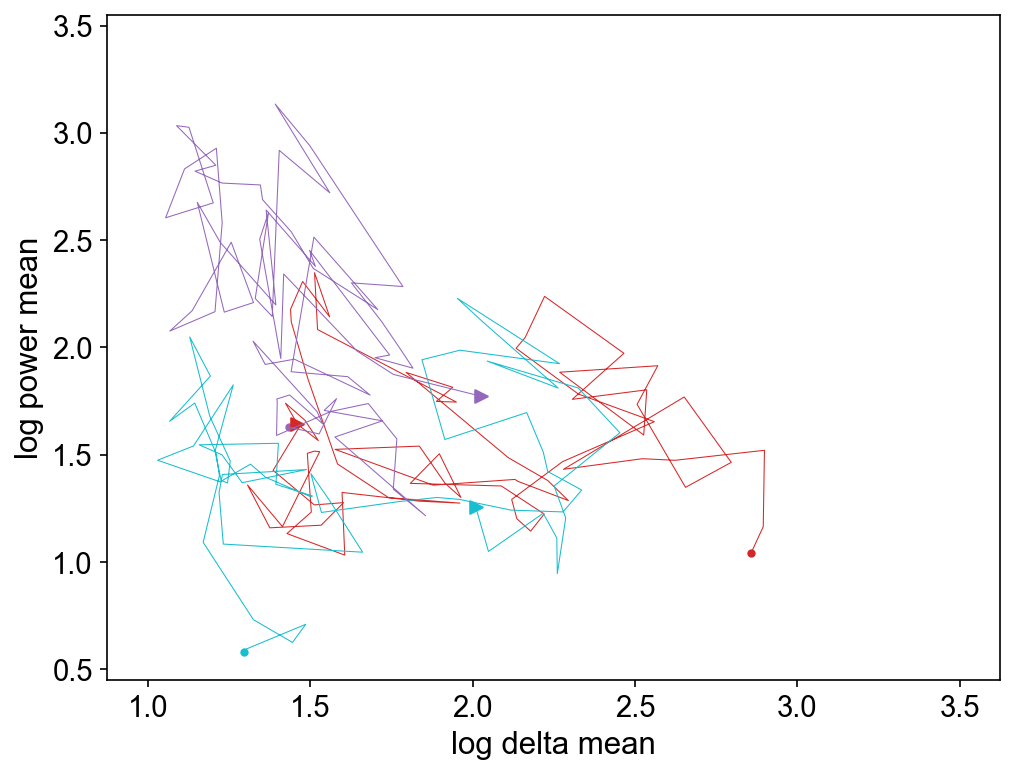

In [12]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.xlabel("log delta mean",size=15,fontname="Arial")
plt.ylabel("log power mean",size=15,fontname="Arial")
plt.xticks(size=14)
plt.yticks(size=14)
plt.xlim([1.0-0.125,3.5+0.125])
plt.ylim([0.5-0.05,3.5+0.05])

palette = sns.color_palette(n_colors = sim_num)
watch_list = [153, 309, 344]
for j in tqdm(watch_list,leave=False):
    plt.plot(np.exp(logPara_histories['logdelta '+str(j)]),np.exp(logPara_histories['logpower '+str(j)]), linewidth = 0.5, color = palette[j])

for j in tqdm(watch_list,leave=False):
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].head(1)),np.exp(logPara_histories['logpower '+str(j)].head(1)), marker = '.', color = palette[j])

for j in tqdm(watch_list,leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[j])

for j in tqdm(watch_list,leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].tail(1)),np.exp(logPara_histories['logpower '+str(j)].tail(1)), marker = '>', color = palette[j])

plt.savefig("Evo_Fig/Rev_1 simulated parameters.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [13]:
logPara_histories_rev_delta = logPara_histories_rev[logPara_histories_rev.columns[logPara_histories_rev.columns.str.startswith("logdelta")]]
logPara_histories_rev_delta

,logdelta 0,logdelta 1,logdelta 2,logdelta 3,logdelta 4,logdelta 5,logdelta 6,logdelta 7,logdelta 8,logdelta 9,...,logdelta 9990,logdelta 9991,logdelta 9992,logdelta 9993,logdelta 9994,logdelta 9995,logdelta 9996,logdelta 9997,logdelta 9998,logdelta 9999
0,0.302447,0.22697,0.417707,0.030729,0.396423,0.25996,0.214055,0.644256,0.085749,1.06891,...,0.329878,0.599621,0.184801,0.336196,0.206605,0.263001,0.108068,0.085549,0.632158,0.287387
1,0.189900,0.22700,0.594800,0.054400,0.304300,0.30440,0.162800,0.592400,-0.008300,1.13850,...,0.329900,0.599600,0.080200,0.384300,0.239600,0.249900,0.108100,0.099900,0.743600,0.287400
2,0.234500,0.22700,0.662900,0.054400,0.339000,0.45800,0.041300,0.455800,-0.008300,1.04310,...,0.441100,0.582200,0.080200,0.384300,0.244300,0.360300,0.176900,0.068700,0.743600,0.287400
3,0.165800,0.07400,0.686800,0.023300,0.485200,0.47930,0.070700,0.447900,0.046800,1.11370,...,0.326200,0.682000,0.096600,0.322100,0.244300,0.326300,0.244100,0.004200,0.743600,0.377300
4,0.165800,0.15830,0.488100,-0.031600,0.412300,0.57040,0.011900,0.447900,0.163400,1.17410,...,0.379500,0.682000,0.259100,0.322100,0.398400,0.326300,0.390200,0.139700,0.743600,0.437500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.496000,0.39330,0.405000,0.552200,0.644700,0.38070,0.594000,0.639800,0.591700,0.25520,...,0.469700,0.615000,0.504200,0.604900,0.661900,0.758800,0.478500,0.718800,0.758600,0.912700
97,0.447300,0.44840,0.405000,0.486400,0.516000,0.36750,0.540100,0.623200,0.557000,0.25520,...,0.432400,0.615000,0.455100,0.604900,0.745900,0.758800,0.478500,0.789900,0.758600,0.847900
98,0.531600,0.44840,0.400200,0.486400,0.678900,0.34110,0.546500,0.623200,0.560700,0.06820,...,0.191300,0.554500,0.410200,0.604900,0.745900,0.886200,0.367100,0.802100,0.758600,0.736400
99,0.631500,0.54100,0.477500,0.360400,0.622200,0.15540,0.484700,0.623200,0.419900,0.22480,...,0.301500,0.607500,0.410200,0.654500,0.744400,0.886200,0.186600,0.835100,0.944400,0.528400


In [14]:
logPara_histories_rev_power = logPara_histories_rev[logPara_histories_rev.columns[logPara_histories_rev.columns.str.startswith("logpower")]]
logPara_histories_rev_power

,logpower 0,logpower 1,logpower 2,logpower 3,logpower 4,logpower 5,logpower 6,logpower 7,logpower 8,logpower 9,...,logpower 9990,logpower 9991,logpower 9992,logpower 9993,logpower 9994,logpower 9995,logpower 9996,logpower 9997,logpower 9998,logpower 9999
0,0.431105,-0.231822,0.036302,0.015013,0.235764,0.050755,-0.070829,0.02494,0.25295,-1.165343,...,0.027758,0.011951,0.133718,0.208927,-0.107732,0.220955,0.283268,-0.182882,0.487543,-0.254249
1,0.418200,-0.231800,-0.051900,0.090400,0.372300,-0.168800,-0.066500,0.03040,0.22860,-1.157100,...,0.027800,0.012000,0.281800,0.407400,-0.135500,0.371600,0.283300,0.067500,0.539100,-0.254200
2,0.368600,-0.231800,0.108400,0.090400,0.273900,-0.084700,0.118600,0.15320,0.22860,-1.166200,...,-0.199900,0.026800,0.281800,0.407400,-0.182400,0.231800,0.144000,0.172000,0.539100,-0.254200
3,0.364900,-0.098500,0.140800,0.073100,0.073300,0.046400,-0.030600,0.17980,0.44170,-0.970100,...,-0.274400,-0.080600,0.274900,0.329600,-0.182400,0.263800,0.211600,0.107000,0.539100,0.046400
4,0.364900,0.171000,0.484100,0.251600,0.179600,-0.045300,0.211200,0.17980,0.13920,-1.049500,...,-0.124800,-0.080600,0.366900,0.329600,-0.133100,0.263800,0.413500,0.225700,0.539100,0.273200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.771500,0.403500,0.397200,0.608200,0.242900,0.805900,0.250500,0.26470,0.14130,0.632500,...,0.291500,0.603300,0.876200,0.449600,-0.072800,0.717200,0.594700,0.382600,0.486300,0.130200
97,0.839700,0.547500,0.397200,0.593200,0.468000,0.632200,0.447300,0.37490,0.10640,0.632500,...,0.247800,0.603300,0.978000,0.449600,0.035700,0.717200,0.594700,0.160000,0.486300,0.014800
98,0.750500,0.547500,0.398400,0.593200,0.359700,0.582700,0.347900,0.37490,0.14020,0.636500,...,0.103500,0.554800,1.035100,0.449600,0.035700,0.726800,0.699400,0.103400,0.486300,0.245300
99,0.589500,0.546300,0.171300,0.664100,0.426600,0.528200,0.396000,0.37490,0.21290,0.458000,...,0.175700,0.518100,1.035100,0.499600,0.157500,0.726800,0.560400,0.221500,0.340100,0.554000


In [15]:
logPara_histories_rev_delta_mean = logPara_histories_rev_delta.mean(axis=1)
logPara_histories_rev_power_mean = logPara_histories_rev_power.mean(axis=1)

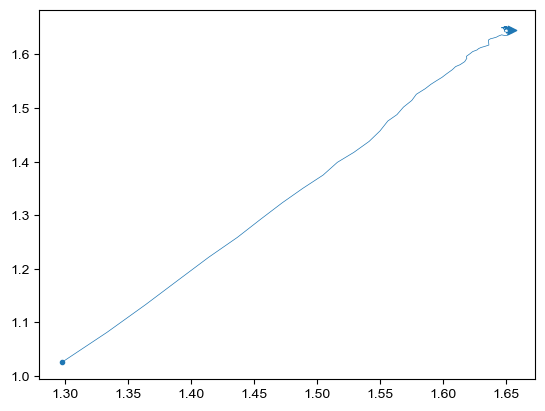

In [16]:
plt.plot(np.exp(logPara_histories_rev_delta_mean),np.exp(logPara_histories_rev_power_mean), linewidth = 0.5, color = palette[0])
plt.scatter(np.exp(logPara_histories_rev_delta_mean.head(1)),np.exp(logPara_histories_rev_power_mean.head(1)), marker = '.', color = palette[0])
plt.scatter(np.exp(logPara_histories_rev_delta_mean.tail(1)),np.exp(logPara_histories_rev_power_mean.tail(1)), marker = '>', color = palette[0])
plt.show()

In [17]:
survival_simulation_counts = pd.DataFrame()
for i in tqdm(range(revo_num+1),leave=False):
    survival_simulation_count_tmp = sim_num - np.sum(np.isnan(logPara_histories.loc[i]))/2
    survival_simulation_counts = pd.concat([survival_simulation_counts, pd.DataFrame([survival_simulation_count_tmp], index = [i], columns = ['Survivors'])], axis=0)

  0%|          | 0/101 [00:00<?, ?it/s]

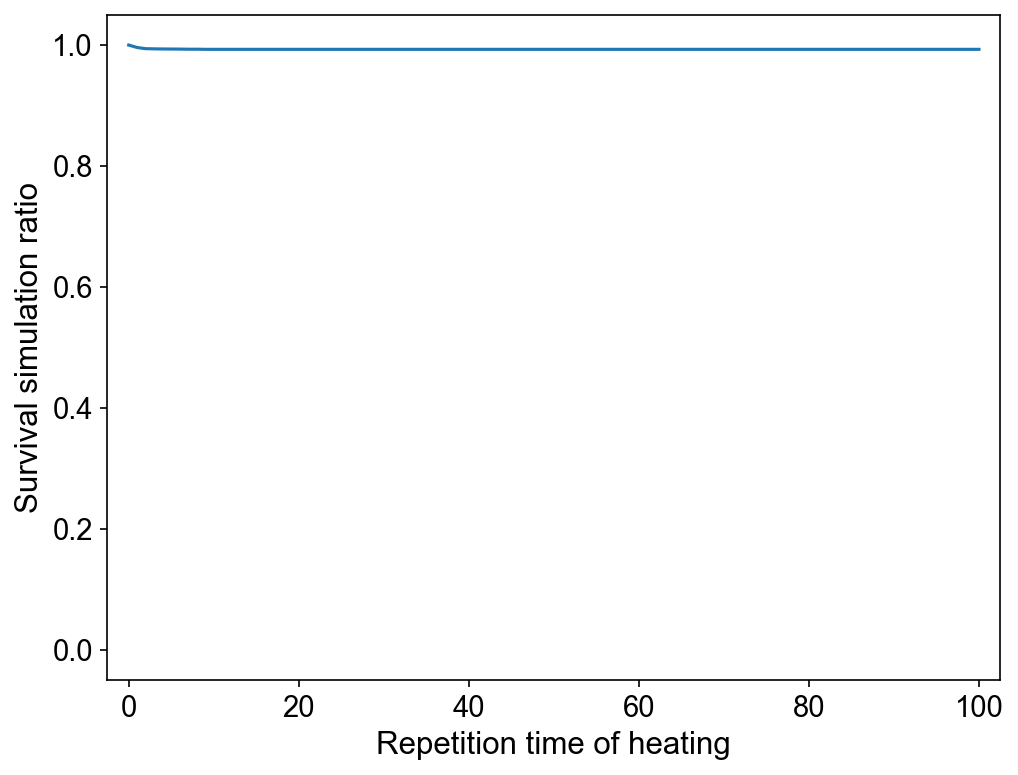

In [18]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.ylabel("Survival simulation ratio",size=15,fontname="Arial")
plt.xlabel("Repetition time of heating",size=15,fontname="Arial")
plt.plot(range(revo_num+1),survival_simulation_counts/sim_num, color = palette[0])
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim([-0.05,1.05])
plt.xlim([-2.5,revo_num+2.5])
plt.savefig("Evo_Fig/Rev_1 simulation counts.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [19]:
survival_simulation_counts

,Survivors
0,10000.0
1,9959.0
2,9940.0
3,9937.0
4,9935.0
...,...
96,9929.0
97,9929.0
98,9929.0
99,9929.0


In [20]:
Survival_simulation_ratio_rev = survival_simulation_counts/sim_num

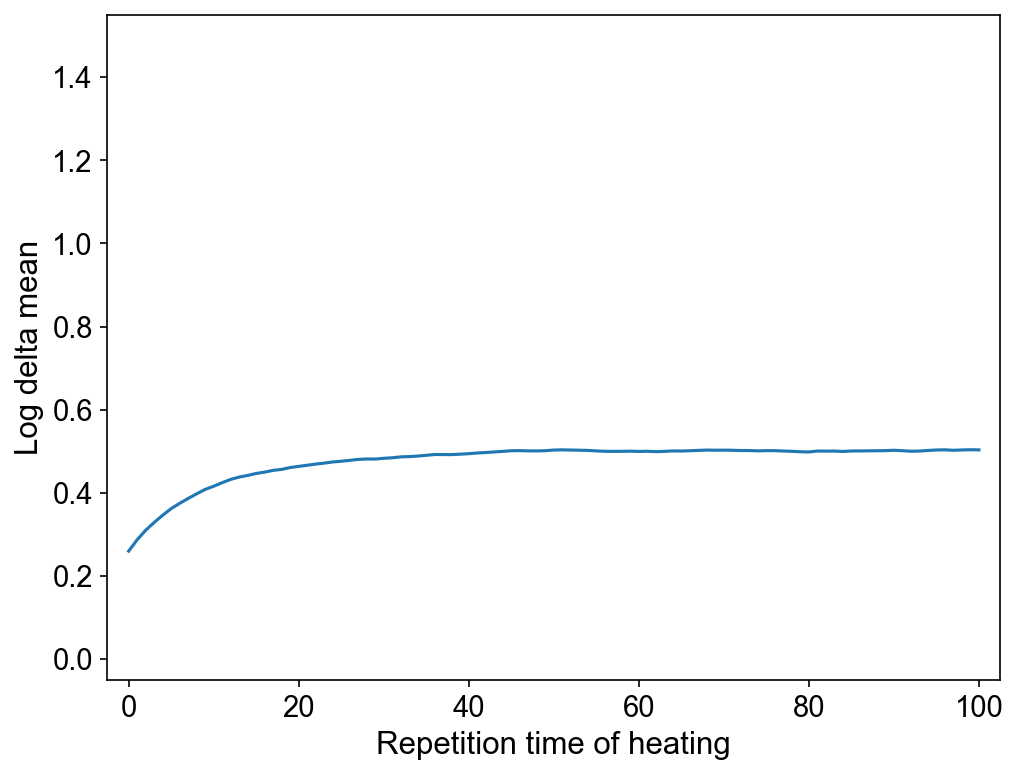

In [21]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.ylabel("Log delta mean",size=15,fontname="Arial")
plt.xlabel("Repetition time of heating",size=15,fontname="Arial")
plt.plot(range(revo_num+1),logPara_histories_rev_delta_mean, color = palette[0])
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim([-0.05,1.55])
plt.xlim([-2.5,revo_num+2.5])
plt.savefig("Evo_Fig/Rev_1_delta_mean.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [22]:
t_heating = 4*delta0_mean
warnings.simplefilter('ignore', RuntimeWarning)
Sim_results =[]
ns = range(sim_num)
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(heat_rev, ns)
logPara_histories = [r for r in ret]
logPara_histories = pd.concat(logPara_histories, axis=1)

In [23]:
logPara_histories

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.344000,0.592900,0.27850,-0.356600,0.620200,-0.119500,NaN,NaN,0.396400,0.235800,...,0.433200,0.138700,0.196500,0.447600,NaN,NaN,0.743400,0.480200,0.374800,-0.153100
2,0.418100,0.581600,NaN,NaN,0.569400,-0.067900,NaN,NaN,0.396400,0.235800,...,0.299100,0.183000,0.360400,0.507300,NaN,NaN,0.733000,0.436400,NaN,NaN
3,0.357800,0.518000,NaN,NaN,0.656100,-0.185700,NaN,NaN,0.515500,0.164000,...,0.269600,0.153300,0.614400,0.436700,NaN,NaN,0.761200,0.365600,NaN,NaN
4,0.456700,0.523000,NaN,NaN,0.692800,0.062600,NaN,NaN,0.405100,0.278600,...,0.287100,0.308300,0.486600,0.523400,NaN,NaN,0.761200,0.365600,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.467500,0.956300,NaN,NaN,0.891500,0.956400,NaN,NaN,0.734700,0.878400,...,0.519200,0.988200,0.968600,0.558900,NaN,NaN,0.949400,0.669900,NaN,NaN
97,0.467500,0.956300,NaN,NaN,1.011800,0.894300,NaN,NaN,0.669300,0.788000,...,0.519200,0.988200,0.739200,0.834000,NaN,NaN,0.877600,0.814000,NaN,NaN
98,0.408900,1.129600,NaN,NaN,1.011800,0.894300,NaN,NaN,0.442300,0.853100,...,0.519200,0.988200,0.739200,0.834000,NaN,NaN,0.649800,1.094600,NaN,NaN
99,0.473700,1.128500,NaN,NaN,1.011800,0.894300,NaN,NaN,0.542000,0.782600,...,0.511600,0.949800,0.703200,1.009700,NaN,NaN,0.673300,1.174700,NaN,NaN


palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(logPara_histories['logdelta '+str(j)],logPara_histories['logpower '+str(j)], linewidth = 0.5, color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    plt.scatter(logPara_histories['logdelta '+str(j)].head(1),logPara_histories['logpower '+str(j)].head(1), marker = '.', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories['logdelta '+str(j)].tail(1),logPara_histories['logpower '+str(j)].tail(1), marker = '>', color = palette[j], alpha=0.1)
plt.show()

palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(np.exp(logPara_histories['logdelta '+str(j)]),np.exp(logPara_histories['logpower '+str(j)]), linewidth = 0.5, color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].head(1)),np.exp(logPara_histories['logpower '+str(j)].head(1)), marker = '.', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].tail(1)),np.exp(logPara_histories['logpower '+str(j)].tail(1)), marker = '>', color = palette[j], alpha=0.1)
plt.show()

In [24]:
with open('Simulated revolution_2.pkl', 'wb') as g:
    pickle.dump(logPara_histories, g)

In [25]:
logPara_histories_rev_2 = logPara_histories

In [26]:
logPara_histories_rev_2

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.344000,0.592900,0.27850,-0.356600,0.620200,-0.119500,NaN,NaN,0.396400,0.235800,...,0.433200,0.138700,0.196500,0.447600,NaN,NaN,0.743400,0.480200,0.374800,-0.153100
2,0.418100,0.581600,NaN,NaN,0.569400,-0.067900,NaN,NaN,0.396400,0.235800,...,0.299100,0.183000,0.360400,0.507300,NaN,NaN,0.733000,0.436400,NaN,NaN
3,0.357800,0.518000,NaN,NaN,0.656100,-0.185700,NaN,NaN,0.515500,0.164000,...,0.269600,0.153300,0.614400,0.436700,NaN,NaN,0.761200,0.365600,NaN,NaN
4,0.456700,0.523000,NaN,NaN,0.692800,0.062600,NaN,NaN,0.405100,0.278600,...,0.287100,0.308300,0.486600,0.523400,NaN,NaN,0.761200,0.365600,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.467500,0.956300,NaN,NaN,0.891500,0.956400,NaN,NaN,0.734700,0.878400,...,0.519200,0.988200,0.968600,0.558900,NaN,NaN,0.949400,0.669900,NaN,NaN
97,0.467500,0.956300,NaN,NaN,1.011800,0.894300,NaN,NaN,0.669300,0.788000,...,0.519200,0.988200,0.739200,0.834000,NaN,NaN,0.877600,0.814000,NaN,NaN
98,0.408900,1.129600,NaN,NaN,1.011800,0.894300,NaN,NaN,0.442300,0.853100,...,0.519200,0.988200,0.739200,0.834000,NaN,NaN,0.649800,1.094600,NaN,NaN
99,0.473700,1.128500,NaN,NaN,1.011800,0.894300,NaN,NaN,0.542000,0.782600,...,0.511600,0.949800,0.703200,1.009700,NaN,NaN,0.673300,1.174700,NaN,NaN


In [27]:
logPara_histories.dropna(axis=1)

,logdelta 0,logpower 0,logdelta 2,logpower 2,logdelta 4,logpower 4,logdelta 5,logpower 5,logdelta 7,logpower 7,...,logdelta 9991,logpower 9991,logdelta 9993,logpower 9993,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9998,logpower 9998
0,0.302447,0.431105,0.417707,0.036302,0.396423,0.235764,0.25996,0.050755,0.644256,0.02494,...,0.599621,0.011951,0.336196,0.208927,0.263001,0.220955,0.108068,0.283268,0.632158,0.487543
1,0.344000,0.592900,0.620200,-0.119500,0.396400,0.235800,0.42610,0.298100,0.699100,0.07930,...,0.599600,0.012000,0.338700,0.298300,0.433200,0.138700,0.196500,0.447600,0.743400,0.480200
2,0.418100,0.581600,0.569400,-0.067900,0.396400,0.235800,0.52350,0.292900,0.843900,0.09610,...,0.599600,0.012000,0.357100,0.346800,0.299100,0.183000,0.360400,0.507300,0.733000,0.436400
3,0.357800,0.518000,0.656100,-0.185700,0.515500,0.164000,0.46930,0.601700,0.785200,0.31860,...,0.606200,0.269400,0.580700,0.323300,0.269600,0.153300,0.614400,0.436700,0.761200,0.365600
4,0.456700,0.523000,0.692800,0.062600,0.405100,0.278600,0.41770,0.641300,0.785200,0.31860,...,0.553200,0.354600,0.580700,0.323300,0.287100,0.308300,0.486600,0.523400,0.761200,0.365600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.467500,0.956300,0.891500,0.956400,0.734700,0.878400,0.94990,0.365500,0.913700,0.42270,...,0.309600,0.751300,0.948200,0.701200,0.519200,0.988200,0.968600,0.558900,0.949400,0.669900
97,0.467500,0.956300,1.011800,0.894300,0.669300,0.788000,0.94990,0.365500,0.913700,0.42270,...,0.190300,0.677600,0.996200,0.730300,0.519200,0.988200,0.739200,0.834000,0.877600,0.814000
98,0.408900,1.129600,1.011800,0.894300,0.442300,0.853100,0.94990,0.365500,0.913700,0.42270,...,0.302400,0.577500,0.996200,0.730300,0.519200,0.988200,0.739200,0.834000,0.649800,1.094600
99,0.473700,1.128500,1.011800,0.894300,0.542000,0.782600,0.94990,0.365500,0.950800,0.30100,...,0.191600,0.578400,0.996200,0.730300,0.511600,0.949800,0.703200,1.009700,0.673300,1.174700


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

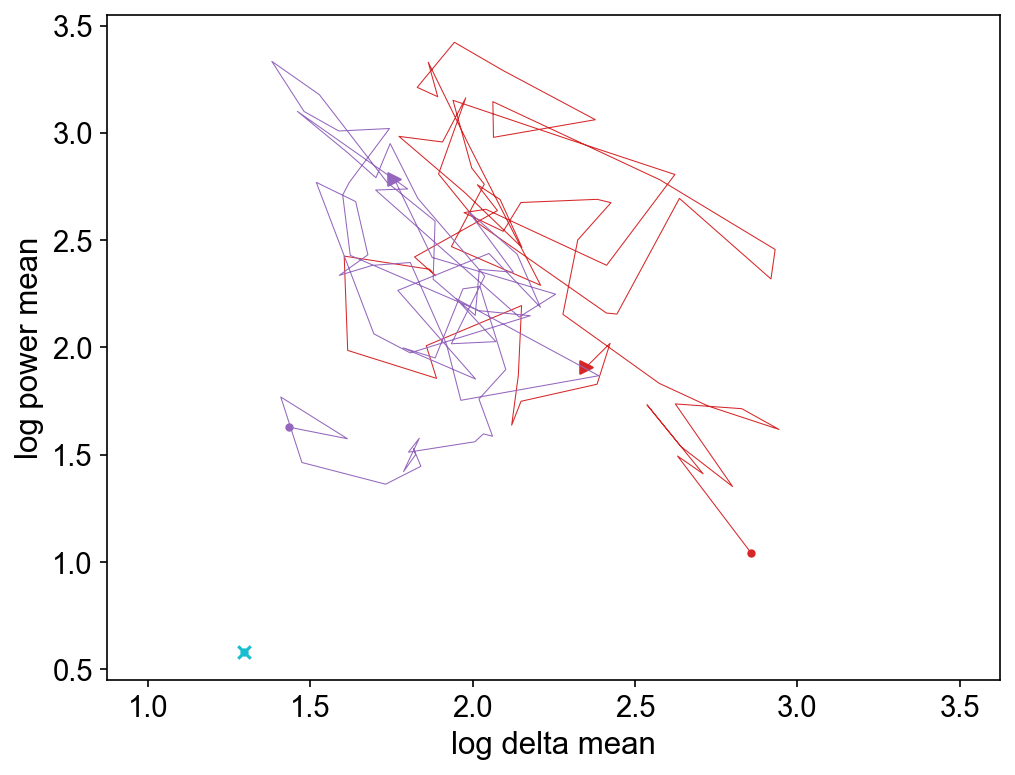

In [28]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.xlabel("log delta mean",size=15,fontname="Arial")
plt.ylabel("log power mean",size=15,fontname="Arial")
plt.xticks(size=14)
plt.yticks(size=14)
plt.xlim([1.0-0.125,3.5+0.125])
plt.ylim([0.5-0.05,3.5+0.05])

palette = sns.color_palette(n_colors = sim_num)
watch_list = [153, 309, 344]
for j in tqdm(watch_list,leave=False):
    plt.plot(np.exp(logPara_histories['logdelta '+str(j)]),np.exp(logPara_histories['logpower '+str(j)]), linewidth = 0.5, color = palette[j])

for j in tqdm(watch_list,leave=False):
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].head(1)),np.exp(logPara_histories['logpower '+str(j)].head(1)), marker = '.', color = palette[j])

for j in tqdm(watch_list,leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[j])

for j in tqdm(watch_list,leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].tail(1)),np.exp(logPara_histories['logpower '+str(j)].tail(1)), marker = '>', color = palette[j])

plt.savefig("Evo_Fig/Rev_2 simulated parameters.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [29]:
logPara_histories_rev_2_delta = logPara_histories_rev_2[logPara_histories_rev_2.columns[logPara_histories_rev_2.columns.str.startswith("logdelta")]]
logPara_histories_rev_2_delta

,logdelta 0,logdelta 1,logdelta 2,logdelta 3,logdelta 4,logdelta 5,logdelta 6,logdelta 7,logdelta 8,logdelta 9,...,logdelta 9990,logdelta 9991,logdelta 9992,logdelta 9993,logdelta 9994,logdelta 9995,logdelta 9996,logdelta 9997,logdelta 9998,logdelta 9999
0,0.302447,0.22697,0.417707,0.030729,0.396423,0.25996,0.214055,0.644256,0.085749,1.06891,...,0.329878,0.599621,0.184801,0.336196,0.206605,0.263001,0.108068,0.085549,0.632158,0.287387
1,0.344000,0.27850,0.620200,NaN,0.396400,0.42610,NaN,0.699100,0.116000,NaN,...,0.218400,0.599600,NaN,0.338700,0.197500,0.433200,0.196500,NaN,0.743400,0.374800
2,0.418100,NaN,0.569400,NaN,0.396400,0.52350,NaN,0.843900,0.177200,NaN,...,0.361100,0.599600,NaN,0.357100,NaN,0.299100,0.360400,NaN,0.733000,NaN
3,0.357800,NaN,0.656100,NaN,0.515500,0.46930,NaN,0.785200,0.342900,NaN,...,0.399800,0.606200,NaN,0.580700,NaN,0.269600,0.614400,NaN,0.761200,NaN
4,0.456700,NaN,0.692800,NaN,0.405100,0.41770,NaN,0.785200,0.301500,NaN,...,0.477700,0.553200,NaN,0.580700,NaN,0.287100,0.486600,NaN,0.761200,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.467500,NaN,0.891500,NaN,0.734700,0.94990,NaN,0.913700,0.787500,NaN,...,0.647600,0.309600,NaN,0.948200,NaN,0.519200,0.968600,NaN,0.949400,NaN
97,0.467500,NaN,1.011800,NaN,0.669300,0.94990,NaN,0.913700,0.802900,NaN,...,0.647600,0.190300,NaN,0.996200,NaN,0.519200,0.739200,NaN,0.877600,NaN
98,0.408900,NaN,1.011800,NaN,0.442300,0.94990,NaN,0.913700,0.802900,NaN,...,0.647600,0.302400,NaN,0.996200,NaN,0.519200,0.739200,NaN,0.649800,NaN
99,0.473700,NaN,1.011800,NaN,0.542000,0.94990,NaN,0.950800,0.790500,NaN,...,0.647600,0.191600,NaN,0.996200,NaN,0.511600,0.703200,NaN,0.673300,NaN


In [30]:
logPara_histories_rev_2_power = logPara_histories_rev_2[logPara_histories_rev_2.columns[logPara_histories_rev_2.columns.str.startswith("logpower")]]
logPara_histories_rev_2_power

,logpower 0,logpower 1,logpower 2,logpower 3,logpower 4,logpower 5,logpower 6,logpower 7,logpower 8,logpower 9,...,logpower 9990,logpower 9991,logpower 9992,logpower 9993,logpower 9994,logpower 9995,logpower 9996,logpower 9997,logpower 9998,logpower 9999
0,0.431105,-0.231822,0.036302,0.015013,0.235764,0.050755,-0.070829,0.02494,0.25295,-1.165343,...,0.027758,0.011951,0.133718,0.208927,-0.107732,0.220955,0.283268,-0.182882,0.487543,-0.254249
1,0.592900,-0.356600,-0.119500,NaN,0.235800,0.298100,NaN,0.07930,0.20690,NaN,...,0.114600,0.012000,NaN,0.298300,-0.107300,0.138700,0.447600,NaN,0.480200,-0.153100
2,0.581600,NaN,-0.067900,NaN,0.235800,0.292900,NaN,0.09610,0.29180,NaN,...,-0.105500,0.012000,NaN,0.346800,NaN,0.183000,0.507300,NaN,0.436400,NaN
3,0.518000,NaN,-0.185700,NaN,0.164000,0.601700,NaN,0.31860,0.32200,NaN,...,0.010400,0.269400,NaN,0.323300,NaN,0.153300,0.436700,NaN,0.365600,NaN
4,0.523000,NaN,0.062600,NaN,0.278600,0.641300,NaN,0.31860,0.42970,NaN,...,0.018300,0.354600,NaN,0.323300,NaN,0.308300,0.523400,NaN,0.365600,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.956300,NaN,0.956400,NaN,0.878400,0.365500,NaN,0.42270,0.55840,NaN,...,0.936600,0.751300,NaN,0.701200,NaN,0.988200,0.558900,NaN,0.669900,NaN
97,0.956300,NaN,0.894300,NaN,0.788000,0.365500,NaN,0.42270,0.57560,NaN,...,0.936600,0.677600,NaN,0.730300,NaN,0.988200,0.834000,NaN,0.814000,NaN
98,1.129600,NaN,0.894300,NaN,0.853100,0.365500,NaN,0.42270,0.57560,NaN,...,0.936600,0.577500,NaN,0.730300,NaN,0.988200,0.834000,NaN,1.094600,NaN
99,1.128500,NaN,0.894300,NaN,0.782600,0.365500,NaN,0.30100,0.58720,NaN,...,0.936600,0.578400,NaN,0.730300,NaN,0.949800,1.009700,NaN,1.174700,NaN


In [31]:
logPara_histories_rev_2_delta_mean = logPara_histories_rev_2_delta.mean(axis=1)
logPara_histories_rev_2_power_mean = logPara_histories_rev_2_power.mean(axis=1)

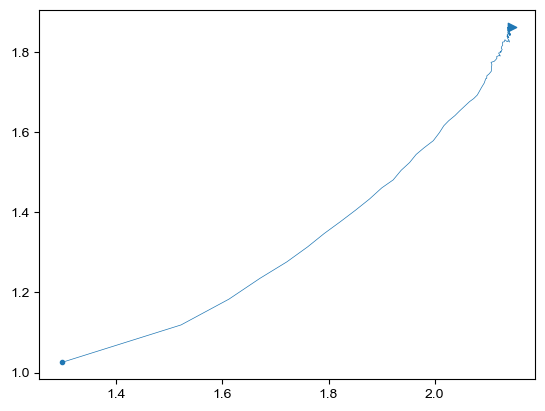

In [32]:
plt.plot(np.exp(logPara_histories_rev_2_delta_mean),np.exp(logPara_histories_rev_2_power_mean), linewidth = 0.5, color = palette[0])
plt.scatter(np.exp(logPara_histories_rev_2_delta_mean.head(1)),np.exp(logPara_histories_rev_2_power_mean.head(1)), marker = '.', color = palette[0])
plt.scatter(np.exp(logPara_histories_rev_2_delta_mean.tail(1)),np.exp(logPara_histories_rev_2_power_mean.tail(1)), marker = '>', color = palette[0])
plt.show()

In [33]:
survival_simulation_counts = pd.DataFrame()
for i in tqdm(range(revo_num+1),leave=False):
    survival_simulation_count_tmp = sim_num - np.sum(np.isnan(logPara_histories.loc[i]))/2
    survival_simulation_counts = pd.concat([survival_simulation_counts, pd.DataFrame([survival_simulation_count_tmp], index = [i], columns = ['Survivors'])], axis=0)

  0%|          | 0/101 [00:00<?, ?it/s]

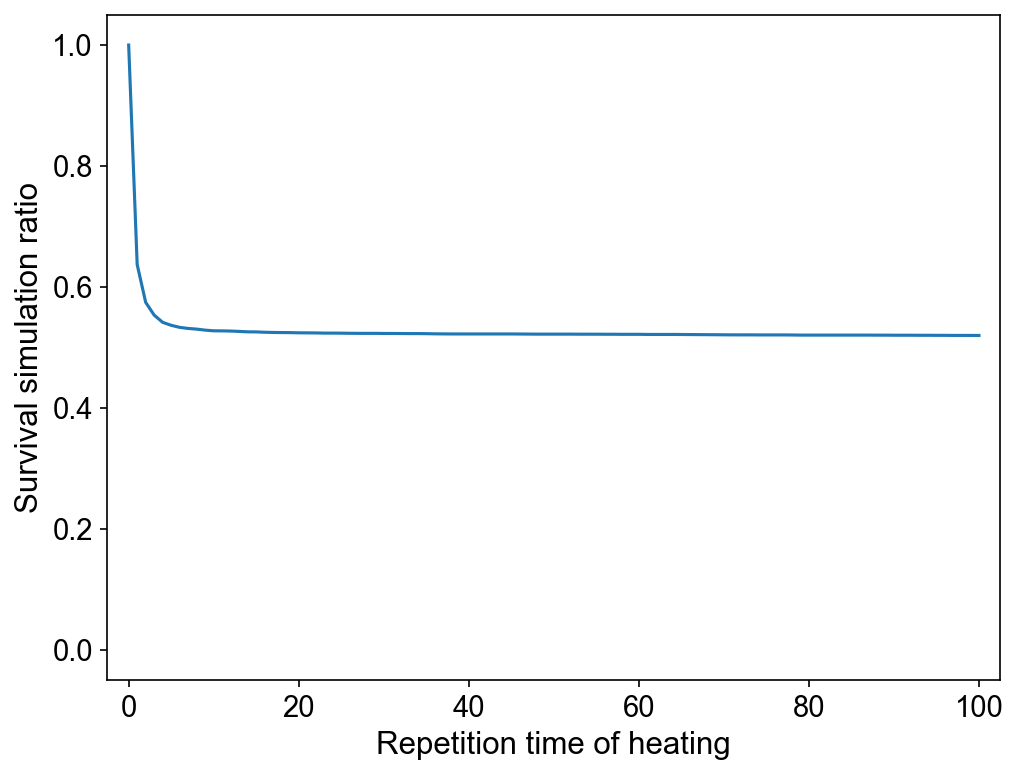

In [34]:

plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.ylabel("Survival simulation ratio",size=15,fontname="Arial")
plt.xlabel("Repetition time of heating",size=15,fontname="Arial")
plt.plot(range(revo_num+1),survival_simulation_counts/sim_num, color = palette[0])
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim([-0.05,1.05])
plt.xlim([-2.5,revo_num+2.5])
plt.savefig("Evo_Fig/Rev_2 simulation counts.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [35]:
survival_simulation_counts

,Survivors
0,10000.0
1,6370.0
2,5746.0
3,5534.0
4,5415.0
...,...
96,5200.0
97,5199.0
98,5199.0
99,5199.0


In [36]:
Survival_simulation_ratio_rev_2 = survival_simulation_counts/sim_num

In [37]:
t_heating = 6*delta0_mean
warnings.simplefilter('ignore', RuntimeWarning)
Sim_results =[]
ns = range(sim_num)
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(heat_rev, ns)
logPara_histories = [r for r in ret]
logPara_histories = pd.concat(logPara_histories, axis=1)

In [38]:
logPara_histories

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.338600,0.448700,NaN,NaN,NaN,NaN,NaN,NaN,0.500300,0.365000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.632200,0.487500,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.611000,0.537700,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.709200,0.656200,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.709200,0.656200,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.001300,0.677800,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.001300,0.677800,NaN,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.969300,0.683600,NaN,NaN
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.969300,0.683600,NaN,NaN


palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(logPara_histories['logdelta '+str(j)],logPara_histories['logpower '+str(j)], linewidth = 0.5, color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    plt.scatter(logPara_histories['logdelta '+str(j)].head(1),logPara_histories['logpower '+str(j)].head(1), marker = '.', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories['logdelta '+str(j)].tail(1),logPara_histories['logpower '+str(j)].tail(1), marker = '>', color = palette[j], alpha=0.1)
plt.show()

palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(np.exp(logPara_histories['logdelta '+str(j)]),np.exp(logPara_histories['logpower '+str(j)]), linewidth = 0.5, color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].head(1)),np.exp(logPara_histories['logpower '+str(j)].head(1)), marker = '.', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[j], alpha=0.1)

for j in tqdm(range(sim_num),leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].tail(1)),np.exp(logPara_histories['logpower '+str(j)].tail(1)), marker = '>', color = palette[j], alpha=0.1)
plt.show()

In [39]:
with open('Simulated revolution_3.pkl', 'wb') as g:
    pickle.dump(logPara_histories, g)

In [40]:
logPara_histories_rev_3 = logPara_histories

In [41]:
logPara_histories_rev_3

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.338600,0.448700,NaN,NaN,NaN,NaN,NaN,NaN,0.500300,0.365000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.632200,0.487500,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.611000,0.537700,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.709200,0.656200,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.709200,0.656200,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.001300,0.677800,NaN,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.001300,0.677800,NaN,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.969300,0.683600,NaN,NaN
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.969300,0.683600,NaN,NaN


In [42]:
logPara_histories.dropna(axis=1)

,logdelta 26,logpower 26,logdelta 61,logpower 61,logdelta 62,logpower 62,logdelta 64,logpower 64,logdelta 80,logpower 80,...,logdelta 9921,logpower 9921,logdelta 9940,logpower 9940,logdelta 9948,logpower 9948,logdelta 9981,logpower 9981,logdelta 9998,logpower 9998
0,0.634444,0.094813,1.029963,-0.12611,1.001272,-0.285358,0.699082,0.085666,0.672606,0.245019,...,0.486661,0.517392,0.494389,0.286631,0.71101,0.111064,0.685672,0.13831,0.632158,0.487543
1,0.634400,0.094800,1.143200,-0.13670,1.017700,-0.143000,0.808300,0.203200,0.868300,0.177000,...,0.583600,0.560700,0.553500,0.251800,0.71100,0.111100,0.773300,0.07250,0.632200,0.487500
2,0.634400,0.094800,1.265100,-0.23910,1.017700,-0.143000,0.902900,0.292600,0.955500,0.011900,...,0.724700,0.520200,0.599900,0.063600,0.49700,0.210400,0.783100,0.14210,0.611000,0.537700
3,0.847600,0.175700,1.265100,-0.23910,0.922600,-0.145100,0.862900,0.352300,0.955500,0.011900,...,0.724700,0.520200,0.713800,0.353900,0.57080,0.410800,0.719900,0.23590,0.709200,0.656200
4,0.847600,0.175700,1.265100,-0.23910,0.922600,-0.145100,0.754900,0.337100,0.955500,0.011900,...,0.685400,0.480400,0.713800,0.353900,0.57080,0.410800,0.808100,0.22510,0.709200,0.656200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.810600,-0.078700,0.704000,0.96120,1.223300,0.903600,0.980400,0.614300,1.148000,0.507400,...,1.067300,0.378500,1.038800,0.286100,0.84970,1.212500,0.985700,1.12040,1.001300,0.677800
97,0.810600,-0.078700,0.757700,0.85500,1.026700,0.903300,0.980400,0.614300,1.149000,0.420900,...,1.118200,0.431000,0.961000,0.505100,0.89210,1.140800,1.095900,1.06200,1.001300,0.677800
98,0.917800,-0.142000,0.757700,0.85500,0.976800,0.906700,0.980400,0.614300,1.277500,0.588400,...,1.118200,0.431000,0.991700,0.426200,0.87910,0.896200,1.095900,1.06200,0.969300,0.683600
99,0.925700,-0.221800,0.683500,0.99840,0.976800,0.906700,0.973500,0.639800,1.277500,0.588400,...,1.118200,0.431000,0.974200,0.380100,0.96140,0.766200,1.095900,1.06200,0.969300,0.683600


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

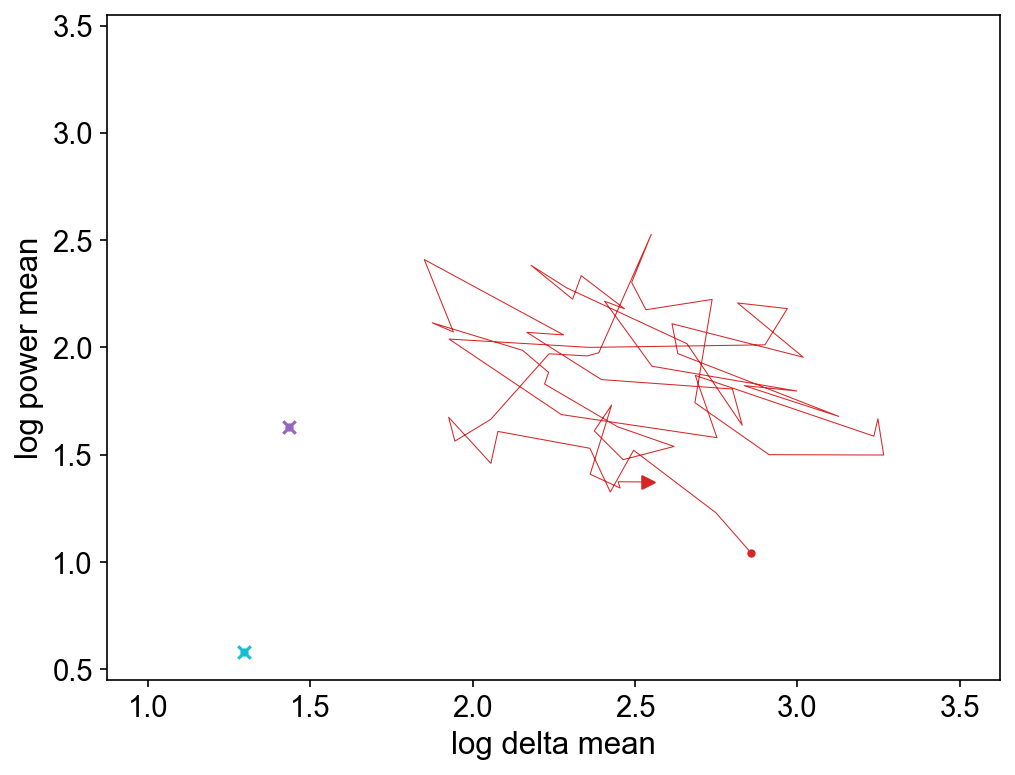

In [43]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.xlabel("log delta mean",size=15,fontname="Arial")
plt.ylabel("log power mean",size=15,fontname="Arial")
plt.xticks(size=14)
plt.yticks(size=14)
plt.xlim([1.0-0.125,3.5+0.125])
plt.ylim([0.5-0.05,3.5+0.05])

palette = sns.color_palette(n_colors = sim_num)
watch_list = [153, 309, 344]
for j in tqdm(watch_list,leave=False):
    plt.plot(np.exp(logPara_histories['logdelta '+str(j)]),np.exp(logPara_histories['logpower '+str(j)]), linewidth = 0.5, color = palette[j])

for j in tqdm(watch_list,leave=False):
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].head(1)),np.exp(logPara_histories['logpower '+str(j)].head(1)), marker = '.', color = palette[j])

for j in tqdm(watch_list,leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[j])

for j in tqdm(watch_list,leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].tail(1)),np.exp(logPara_histories['logpower '+str(j)].tail(1)), marker = '>', color = palette[j])

plt.savefig("Evo_Fig/Rev_3 simulated parameters.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [44]:
logPara_histories_rev_3_delta = logPara_histories_rev_3[logPara_histories_rev_3.columns[logPara_histories_rev_3.columns.str.startswith("logdelta")]]
logPara_histories_rev_3_delta

,logdelta 0,logdelta 1,logdelta 2,logdelta 3,logdelta 4,logdelta 5,logdelta 6,logdelta 7,logdelta 8,logdelta 9,...,logdelta 9990,logdelta 9991,logdelta 9992,logdelta 9993,logdelta 9994,logdelta 9995,logdelta 9996,logdelta 9997,logdelta 9998,logdelta 9999
0,0.302447,0.22697,0.417707,0.030729,0.396423,0.25996,0.214055,0.644256,0.085749,1.06891,...,0.329878,0.599621,0.184801,0.336196,0.206605,0.263001,0.108068,0.085549,0.632158,0.287387
1,0.338600,NaN,NaN,NaN,0.500300,NaN,NaN,0.756600,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.632200,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.841600,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.611000,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.841600,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.709200,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.709200,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.001300,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.001300,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.969300,NaN
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.969300,NaN


In [45]:
logPara_histories_rev_3_power = logPara_histories_rev_3[logPara_histories_rev_3.columns[logPara_histories_rev_3.columns.str.startswith("logpower")]]
logPara_histories_rev_3_power

,logpower 0,logpower 1,logpower 2,logpower 3,logpower 4,logpower 5,logpower 6,logpower 7,logpower 8,logpower 9,...,logpower 9990,logpower 9991,logpower 9992,logpower 9993,logpower 9994,logpower 9995,logpower 9996,logpower 9997,logpower 9998,logpower 9999
0,0.431105,-0.231822,0.036302,0.015013,0.235764,0.050755,-0.070829,0.02494,0.25295,-1.165343,...,0.027758,0.011951,0.133718,0.208927,-0.107732,0.220955,0.283268,-0.182882,0.487543,-0.254249
1,0.448700,NaN,NaN,NaN,0.365000,NaN,NaN,0.03790,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.487500,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.07570,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.537700,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.07570,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.656200,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.656200,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.677800,NaN
97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.677800,NaN
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.683600,NaN
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.683600,NaN


In [46]:
logPara_histories_rev_3_delta_mean = logPara_histories_rev_3_delta.mean(axis=1)
logPara_histories_rev_3_power_mean = logPara_histories_rev_3_power.mean(axis=1)

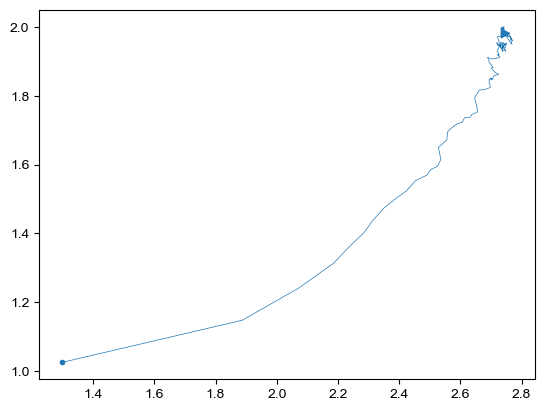

In [47]:
plt.plot(np.exp(logPara_histories_rev_3_delta_mean),np.exp(logPara_histories_rev_3_power_mean), linewidth = 0.5, color = palette[0])
plt.scatter(np.exp(logPara_histories_rev_3_delta_mean.head(1)),np.exp(logPara_histories_rev_3_power_mean.head(1)), marker = '.', color = palette[0])
plt.scatter(np.exp(logPara_histories_rev_3_delta_mean.tail(1)),np.exp(logPara_histories_rev_3_power_mean.tail(1)), marker = '>', color = palette[0])
plt.show()

In [48]:
survival_simulation_counts = pd.DataFrame()
for i in tqdm(range(revo_num+1),leave=False):
    survival_simulation_count_tmp = sim_num - np.sum(np.isnan(logPara_histories.loc[i]))/2
    survival_simulation_counts = pd.concat([survival_simulation_counts, pd.DataFrame([survival_simulation_count_tmp], index = [i], columns = ['Survivors'])], axis=0)

  0%|          | 0/101 [00:00<?, ?it/s]

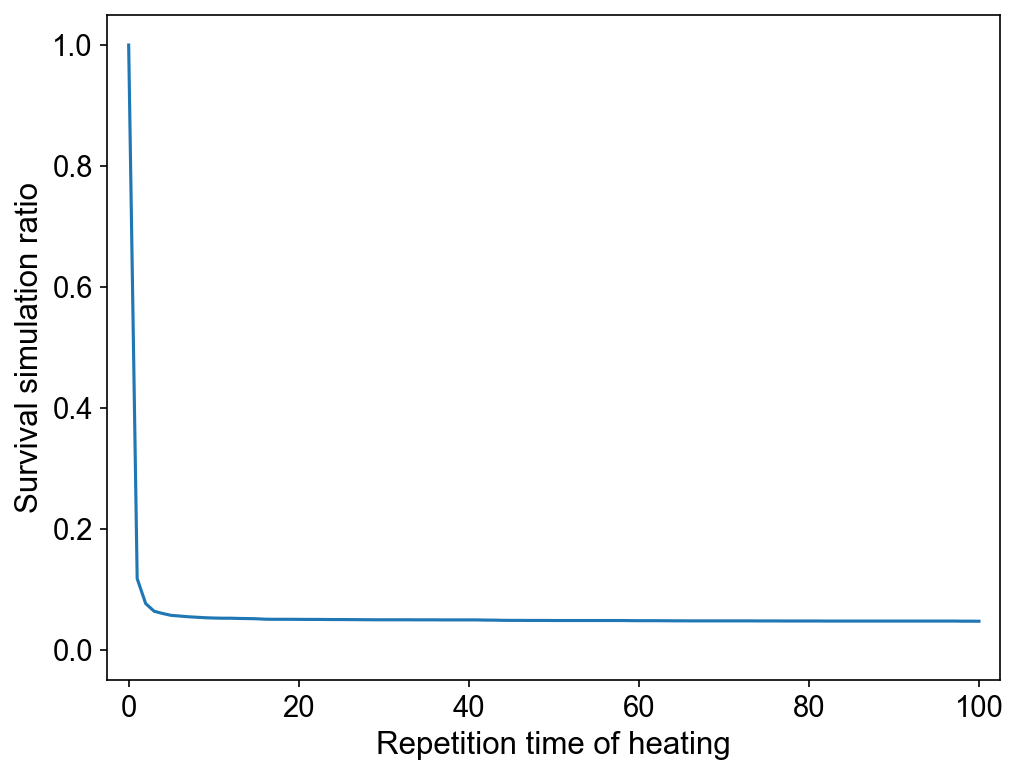

In [49]:

plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.ylabel("Survival simulation ratio",size=15,fontname="Arial")
plt.xlabel("Repetition time of heating",size=15,fontname="Arial")
plt.plot(range(revo_num+1),survival_simulation_counts/sim_num, color = palette[0])
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim([-0.05,1.05])
plt.xlim([-2.5,revo_num+2.5])
plt.savefig("Evo_Fig/Rev_3 simulation counts.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [50]:
survival_simulation_counts

,Survivors
0,10000.0
1,1178.0
2,765.0
3,638.0
4,601.0
...,...
96,476.0
97,476.0
98,474.0
99,474.0


In [51]:
Survival_simulation_ratio_rev_3 = survival_simulation_counts/sim_num

In [52]:
t_heating = 0
warnings.simplefilter('ignore', RuntimeWarning)
Sim_results =[]
ns = range(sim_num)
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(heat_rev, ns)
logPara_histories = [r for r in ret]
logPara_histories = pd.concat(logPara_histories, axis=1)

In [53]:
logPara_histories

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.518800,0.492800,0.15350,-0.019900,0.481400,0.030700,0.107400,0.208900,0.428000,0.286000,...,0.240100,0.184500,0.075900,0.462200,0.163600,0.076000,0.684700,0.517500,0.240500,-0.172500
2,0.610900,0.187400,0.19330,0.173800,0.482600,-0.136700,0.127600,0.145900,0.408100,0.268800,...,0.171100,0.099200,0.071200,0.373900,0.180000,-0.113300,0.740500,0.497000,0.240500,-0.172500
3,0.610900,0.187400,0.26760,0.163700,0.262100,0.019700,0.208800,0.123900,0.477300,0.188500,...,0.055900,0.153200,0.051200,0.488100,0.248300,-0.304600,0.577900,0.521600,0.276200,0.042400
4,0.610900,0.187400,0.36750,0.414300,0.214200,0.060300,0.231500,0.205900,0.469100,0.195700,...,0.068200,0.159400,0.111300,0.347600,0.207800,-0.256500,0.697900,0.376700,0.191700,-0.009500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,-0.015600,-0.444400,-0.27090,-0.387900,0.107300,-0.193300,0.556000,-0.469100,0.205100,0.029800,...,0.333800,-0.259800,0.141300,0.048400,0.586000,-0.021000,0.217800,-0.435700,0.264100,0.176700
97,-0.058800,-0.398400,-0.32390,-0.308900,0.047300,-0.225300,0.556000,-0.469100,0.395500,0.058400,...,0.421700,-0.243600,0.142100,0.061100,0.525500,0.189500,0.205400,-0.387500,0.318000,0.035400
98,-0.066300,-0.309500,-0.32390,-0.308900,0.028200,-0.202500,0.457900,-0.464000,0.377800,0.085200,...,0.499200,-0.155900,0.286600,0.228300,0.520500,0.152400,0.383300,-0.374300,0.318000,0.035400
99,0.011200,-0.289400,-0.19720,-0.453200,0.132400,-0.304200,0.457900,-0.464000,0.353600,0.027200,...,0.331300,0.093300,0.317800,0.261300,0.561000,0.104200,0.383300,-0.374300,0.386200,0.008000


palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(logPara_histories['logdelta '+str(j)],logPara_histories['logpower '+str(j)], linewidth = 0.5, color = palette[j], alpha=0.1)
for j in tqdm(range(sim_num),leave=False):
    plt.scatter(logPara_histories['logdelta '+str(j)].head(1),logPara_histories['logpower '+str(j)].head(1), marker = '.', color = palette[j], alpha=0.1)
for j in tqdm(range(sim_num),leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[j], alpha=0.1)
for j in tqdm(range(sim_num),leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories['logdelta '+str(j)].tail(1),logPara_histories['logpower '+str(j)].tail(1), marker = '>', color = palette[j], alpha=0.1)
plt.show()

palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(np.exp(logPara_histories['logdelta '+str(j)]),np.exp(logPara_histories['logpower '+str(j)]), linewidth = 0.5, color = palette[j], alpha=0.1)
for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].head(1)),np.exp(logPara_histories['logpower '+str(j)].head(1)), marker = '.', color = palette[j], alpha=0.1)
for j in tqdm(range(sim_num),leave=False):
    if np.isnan(logPara_histories['logdelta '+str(j)].tail(1).iloc[0]):
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].dropna(how='all', axis=1).tail(1)),np.exp(logPara_histories['logpower '+str(j)].dropna(how='all', axis=1).tail(1)), marker = 'x', color = palette[j], alpha=0.1)
for j in tqdm(range(sim_num),leave=False):
    if logPara_histories['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].tail(1)),np.exp(logPara_histories['logpower '+str(j)].tail(1)), marker = '>', color = palette[j], alpha=0.1)
plt.show()

In [54]:
logPara_histories_non = logPara_histories
logPara_histories_non

,logdelta 0,logpower 0,logdelta 1,logpower 1,logdelta 2,logpower 2,logdelta 3,logpower 3,logdelta 4,logpower 4,...,logdelta 9995,logpower 9995,logdelta 9996,logpower 9996,logdelta 9997,logpower 9997,logdelta 9998,logpower 9998,logdelta 9999,logpower 9999
0,0.302447,0.431105,0.22697,-0.231822,0.417707,0.036302,0.030729,0.015013,0.396423,0.235764,...,0.263001,0.220955,0.108068,0.283268,0.085549,-0.182882,0.632158,0.487543,0.287387,-0.254249
1,0.518800,0.492800,0.15350,-0.019900,0.481400,0.030700,0.107400,0.208900,0.428000,0.286000,...,0.240100,0.184500,0.075900,0.462200,0.163600,0.076000,0.684700,0.517500,0.240500,-0.172500
2,0.610900,0.187400,0.19330,0.173800,0.482600,-0.136700,0.127600,0.145900,0.408100,0.268800,...,0.171100,0.099200,0.071200,0.373900,0.180000,-0.113300,0.740500,0.497000,0.240500,-0.172500
3,0.610900,0.187400,0.26760,0.163700,0.262100,0.019700,0.208800,0.123900,0.477300,0.188500,...,0.055900,0.153200,0.051200,0.488100,0.248300,-0.304600,0.577900,0.521600,0.276200,0.042400
4,0.610900,0.187400,0.36750,0.414300,0.214200,0.060300,0.231500,0.205900,0.469100,0.195700,...,0.068200,0.159400,0.111300,0.347600,0.207800,-0.256500,0.697900,0.376700,0.191700,-0.009500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,-0.015600,-0.444400,-0.27090,-0.387900,0.107300,-0.193300,0.556000,-0.469100,0.205100,0.029800,...,0.333800,-0.259800,0.141300,0.048400,0.586000,-0.021000,0.217800,-0.435700,0.264100,0.176700
97,-0.058800,-0.398400,-0.32390,-0.308900,0.047300,-0.225300,0.556000,-0.469100,0.395500,0.058400,...,0.421700,-0.243600,0.142100,0.061100,0.525500,0.189500,0.205400,-0.387500,0.318000,0.035400
98,-0.066300,-0.309500,-0.32390,-0.308900,0.028200,-0.202500,0.457900,-0.464000,0.377800,0.085200,...,0.499200,-0.155900,0.286600,0.228300,0.520500,0.152400,0.383300,-0.374300,0.318000,0.035400
99,0.011200,-0.289400,-0.19720,-0.453200,0.132400,-0.304200,0.457900,-0.464000,0.353600,0.027200,...,0.331300,0.093300,0.317800,0.261300,0.561000,0.104200,0.383300,-0.374300,0.386200,0.008000


  0%|          | 0/10000 [00:00<?, ?it/s]

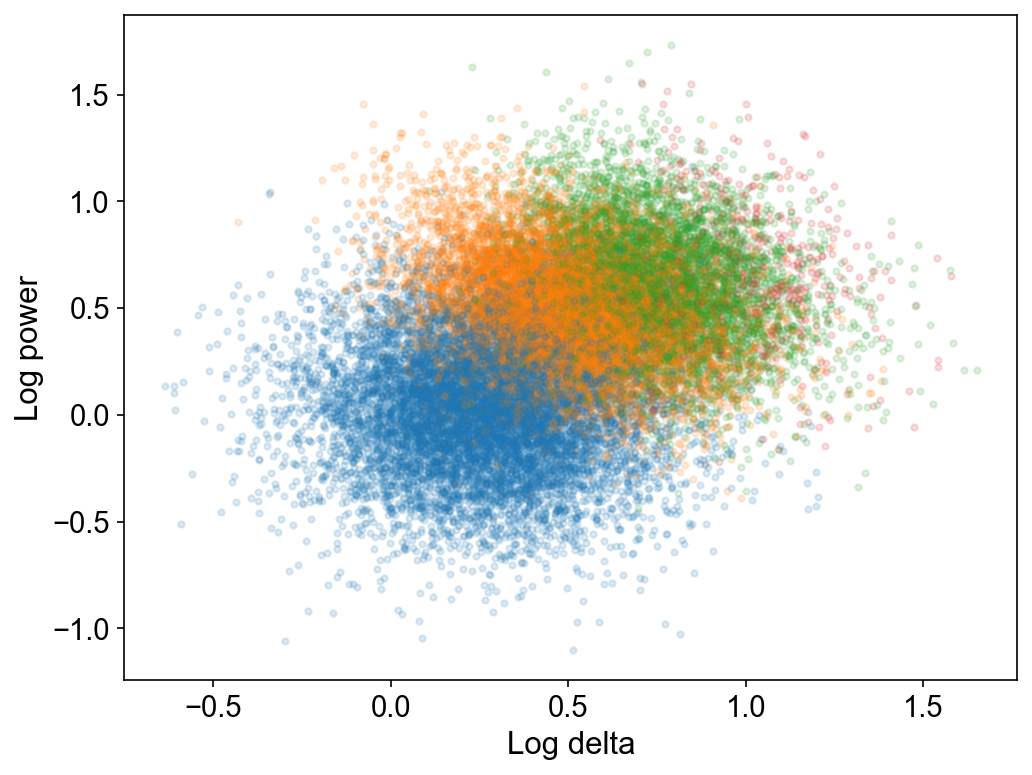

In [55]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.xlabel("Log delta",size=15,fontname="Arial")
plt.ylabel("Log power",size=15,fontname="Arial")
plt.xticks(size=14)
plt.yticks(size=14)


for j in tqdm(range(sim_num),leave=False):
    if logPara_histories_non['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories_non['logdelta '+str(j)].tail(1),logPara_histories_non['logpower '+str(j)].tail(1), marker = '.', color = palette[0], alpha=0.15)
    if logPara_histories_non['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(logPara_histories_non['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories_non['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[0], alpha=0.15)
    
    if logPara_histories_rev['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories_rev['logdelta '+str(j)].tail(1),logPara_histories_rev['logpower '+str(j)].tail(1), marker = '.', color = palette[1], alpha=0.15)
    if logPara_histories_rev['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(logPara_histories_rev['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories_rev['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[1], alpha=0.15)

    if logPara_histories_rev_2['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories_rev_2['logdelta '+str(j)].tail(1),logPara_histories_rev_2['logpower '+str(j)].tail(1), marker = '.', color = palette[2], alpha=0.15)
    if logPara_histories_rev_2['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(logPara_histories_rev_2['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories_rev_2['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[2], alpha=0.15)

    if logPara_histories_rev_3['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories_rev_3['logdelta '+str(j)].tail(1),logPara_histories_rev_3['logpower '+str(j)].tail(1), marker = '.', color = palette[3], alpha=0.15)
    if logPara_histories_rev_3['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(logPara_histories_rev_3['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories_rev_3['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[3], alpha=0.15)

plt.savefig("Evo_Fig/Survival log parameters.pdf", bbox_inches="tight", dpi=150)

plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

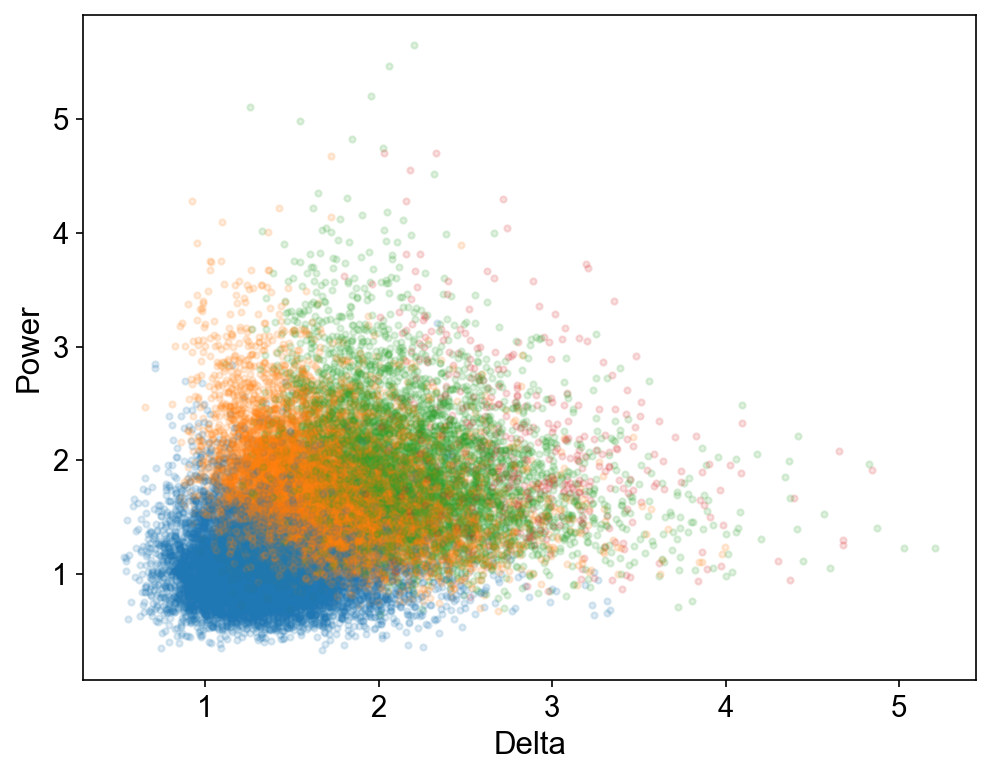

In [56]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.xlabel("Delta",size=15,fontname="Arial")
plt.ylabel("Power",size=15,fontname="Arial")
plt.xticks(size=14)
plt.yticks(size=14)
for j in tqdm(range(sim_num),leave=False):
    if logPara_histories_non['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories_non['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_non['logpower '+str(j)].tail(1)), marker = '.', color = palette[0], alpha=0.15)
    if logPara_histories_non['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(np.exp(logPara_histories_non['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories_non['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[0], alpha=0.15)
    
    if logPara_histories_rev['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories_rev['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev['logpower '+str(j)].tail(1)), marker = '.', color = palette[1], alpha=0.15)
    if logPara_histories_rev['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(np.exp(logPara_histories_rev['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories_rev['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[1], alpha=0.15)

    if logPara_histories_rev_2['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories_rev_2['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev_2['logpower '+str(j)].tail(1)), marker = '.', color = palette[2], alpha=0.15)
    if logPara_histories_rev_2['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(np.exp(logPara_histories_rev_2['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories_rev_2['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[2], alpha=0.15)
        
    if logPara_histories_rev_3['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories_rev_3['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev_3['logpower '+str(j)].tail(1)), marker = '.', color = palette[3], alpha=0.15)
    if logPara_histories_rev_3['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(np.exp(logPara_histories_rev_3['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories_rev_3['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[3], alpha=0.15)
plt.savefig("Evo_Fig/Survival parameters.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [57]:
logPara_histories_rev_0 = logPara_histories
logPara_histories_rev_0_delta = logPara_histories_rev_0[logPara_histories_rev_0.columns[logPara_histories_rev_0.columns.str.startswith("logdelta")]]
logPara_histories_rev_0_power = logPara_histories_rev_0[logPara_histories_rev_0.columns[logPara_histories_rev_0.columns.str.startswith("logpower")]]
logPara_histories_rev_0_delta_mean = logPara_histories_rev_0_delta.mean(axis=1)
logPara_histories_rev_0_power_mean = logPara_histories_rev_0_power.mean(axis=1)

  0%|          | 0/10000 [00:00<?, ?it/s]

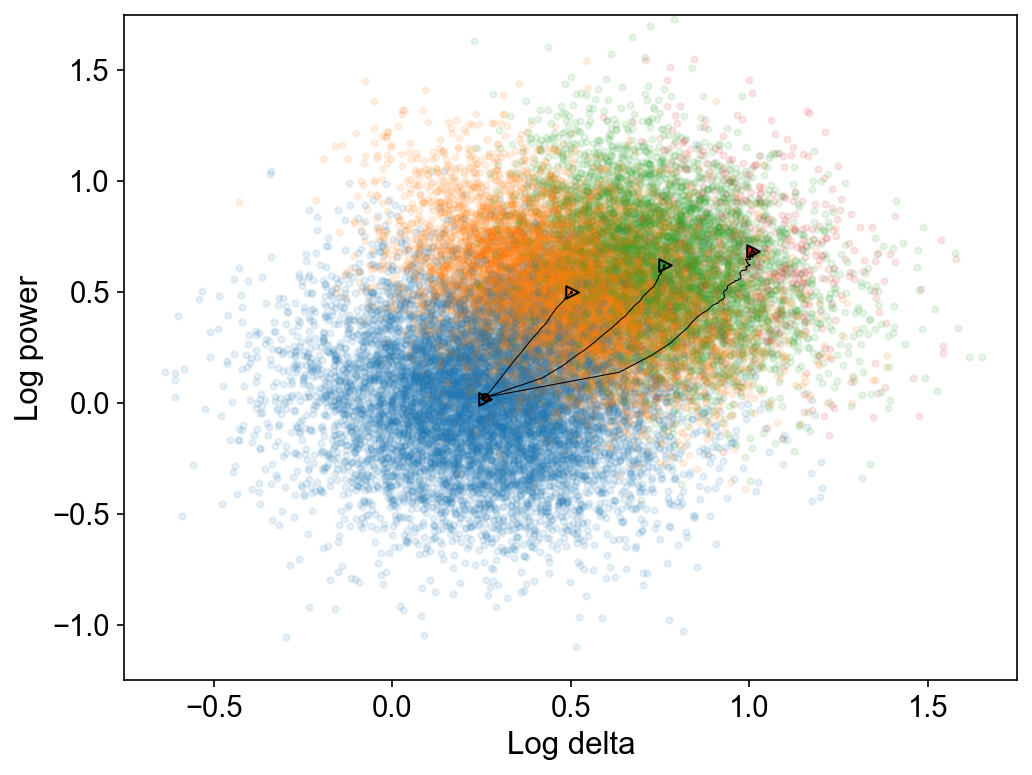

In [58]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.xlabel("Log delta",size=15,fontname="Arial")
plt.ylabel("Log power",size=15,fontname="Arial")
plt.xticks(size=14)
plt.yticks(size=14)

for j in tqdm(range(sim_num),leave=False):
    if logPara_histories_non['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories_non['logdelta '+str(j)].tail(1),logPara_histories_non['logpower '+str(j)].tail(1), marker = '.', color = palette[0], alpha=0.1)
    if logPara_histories_non['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(logPara_histories_non['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories_non['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[0], alpha=0.1)
    
    if logPara_histories_rev['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories_rev['logdelta '+str(j)].tail(1),logPara_histories_rev['logpower '+str(j)].tail(1), marker = '.', color = palette[1], alpha=0.1)
    if logPara_histories_rev['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(logPara_histories_rev['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories_rev['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[1], alpha=0.1)

    if logPara_histories_rev_2['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories_rev_2['logdelta '+str(j)].tail(1),logPara_histories_rev_2['logpower '+str(j)].tail(1), marker = '.', color = palette[2], alpha=0.1)
    if logPara_histories_rev_2['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(logPara_histories_rev_2['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories_rev_2['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[2], alpha=0.1)

    if logPara_histories_rev_3['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(logPara_histories_rev_3['logdelta '+str(j)].tail(1),logPara_histories_rev_3['logpower '+str(j)].tail(1), marker = '.', color = palette[3], alpha=0.1)
    if logPara_histories_rev_3['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(logPara_histories_rev_3['logdelta '+str(j)].dropna(how='all', axis=0).tail(1),logPara_histories_rev_3['logpower '+str(j)].dropna(how='all', axis=0).tail(1), marker = 'x', color = palette[3], alpha=0.1)

plt.plot(logPara_histories_rev_0_delta_mean,logPara_histories_rev_0_power_mean, linewidth = 0.5, color = "black")
plt.scatter(logPara_histories_rev_0_delta_mean.head(1),logPara_histories_rev_0_power_mean.head(1), marker = '.', edgecolors = "black", facecolors = palette[0])
plt.scatter(logPara_histories_rev_0_delta_mean.tail(1),logPara_histories_rev_0_power_mean.tail(1), marker = '>', edgecolors = "black", facecolors = palette[0])

plt.plot(logPara_histories_rev_delta_mean,logPara_histories_rev_power_mean, linewidth = 0.5, color = "black")
plt.scatter(logPara_histories_rev_delta_mean.head(1),logPara_histories_rev_power_mean.head(1), marker = '.', edgecolors = "black", facecolors = palette[1])
plt.scatter(logPara_histories_rev_delta_mean.tail(1),logPara_histories_rev_power_mean.tail(1), marker = '>', edgecolors = "black", facecolors = palette[1])

plt.plot(logPara_histories_rev_2_delta_mean,logPara_histories_rev_2_power_mean, linewidth = 0.5, color = "black")
plt.scatter(logPara_histories_rev_2_delta_mean.head(1),logPara_histories_rev_2_power_mean.head(1), marker = '.', edgecolors = "black", facecolors = palette[2])
plt.scatter(logPara_histories_rev_2_delta_mean.tail(1),logPara_histories_rev_2_power_mean.tail(1), marker = '>', edgecolors = "black", facecolors = palette[2])

plt.plot(logPara_histories_rev_3_delta_mean,logPara_histories_rev_3_power_mean, linewidth = 0.5, color = "black")
plt.scatter(logPara_histories_rev_3_delta_mean.head(1),logPara_histories_rev_3_power_mean.head(1), marker = '.', edgecolors = "black", facecolors = palette[3])
plt.scatter(logPara_histories_rev_3_delta_mean.tail(1),logPara_histories_rev_3_power_mean.tail(1), marker = '>', edgecolors = "black", facecolors = palette[3])
plt.xlim([-0.75,1.75])
plt.ylim([-1.25,1.75])
plt.savefig("Evo_Fig/Survival mean log parameters.pdf", bbox_inches="tight", dpi=150)
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

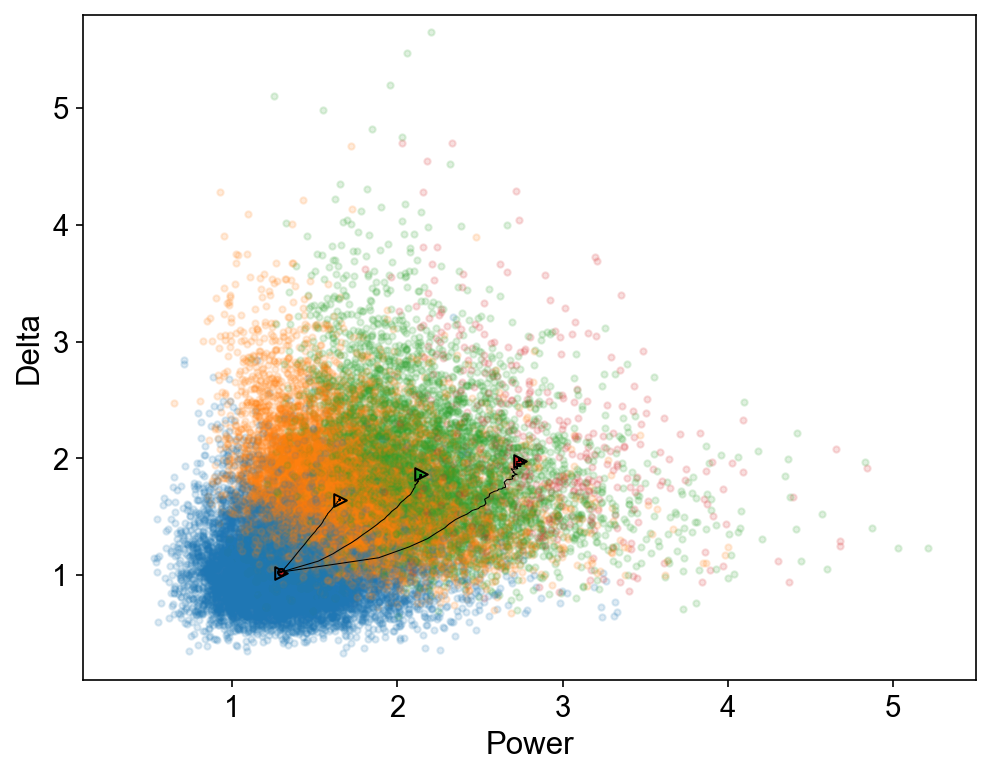

In [59]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.ylabel("Delta",size=15,fontname="Arial")
plt.xlabel("Power",size=15,fontname="Arial")
plt.xticks(size=14)
plt.yticks(size=14)

for j in tqdm(range(sim_num),leave=False):
    if logPara_histories_non['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories_non['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_non['logpower '+str(j)].tail(1)), marker = '.', color = palette[0], alpha=0.15)
    if logPara_histories_non['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(np.exp(logPara_histories_non['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories_non['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[0], alpha=0.15)
    
    if logPara_histories_rev['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories_rev['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev['logpower '+str(j)].tail(1)), marker = '.', color = palette[1], alpha=0.15)
    if logPara_histories_rev['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(np.exp(logPara_histories_rev['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories_rev['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[1], alpha=0.15)

    if logPara_histories_rev_2['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories_rev_2['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev_2['logpower '+str(j)].tail(1)), marker = '.', color = palette[2], alpha=0.15)
    if logPara_histories_rev_2['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(np.exp(logPara_histories_rev_2['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories_rev_2['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[2], alpha=0.15)
        
    if logPara_histories_rev_3['logdelta '+str(j)].tail(1).iloc[0]!=np.nan:
        plt.scatter(np.exp(logPara_histories_rev_3['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev_3['logpower '+str(j)].tail(1)), marker = '.', color = palette[3], alpha=0.15)
    if logPara_histories_rev_3['logdelta '+str(j)].tail(1).iloc[0]==np.nan:
        plt.scatter(np.exp(logPara_histories_rev_3['logdelta '+str(j)].dropna(how='all', axis=0).tail(1)),np.exp(logPara_histories_rev_3['logpower '+str(j)].dropna(how='all', axis=0).tail(1)), marker = 'x', color = palette[3], alpha=0.15)

plt.plot(np.exp(logPara_histories_rev_0_delta_mean),np.exp(logPara_histories_rev_0_power_mean), linewidth = 0.5, color = "black")
plt.scatter(np.exp(logPara_histories_rev_0_delta_mean.head(1)),np.exp(logPara_histories_rev_0_power_mean.head(1)), marker = '.', edgecolors = "black", facecolors = palette[0])
plt.scatter(np.exp(logPara_histories_rev_0_delta_mean.tail(1)),np.exp(logPara_histories_rev_0_power_mean.tail(1)), marker = '>', edgecolors = "black", facecolors = palette[0])

plt.plot(np.exp(logPara_histories_rev_delta_mean),np.exp(logPara_histories_rev_power_mean), linewidth = 0.5, color = "black")
plt.scatter(np.exp(logPara_histories_rev_delta_mean.head(1)),np.exp(logPara_histories_rev_power_mean.head(1)), marker = '.', edgecolors = "black", facecolors = palette[1])
plt.scatter(np.exp(logPara_histories_rev_delta_mean.tail(1)),np.exp(logPara_histories_rev_power_mean.tail(1)), marker = '>', edgecolors = "black", facecolors = palette[1])

plt.plot(np.exp(logPara_histories_rev_2_delta_mean),np.exp(logPara_histories_rev_2_power_mean), linewidth = 0.5, color = "black")
plt.scatter(np.exp(logPara_histories_rev_2_delta_mean.head(1)),np.exp(logPara_histories_rev_2_power_mean.head(1)), marker = '.', edgecolors = "black", facecolors = palette[2])
plt.scatter(np.exp(logPara_histories_rev_2_delta_mean.tail(1)),np.exp(logPara_histories_rev_2_power_mean.tail(1)), marker = '>', edgecolors = "black", facecolors = palette[2])

plt.plot(np.exp(logPara_histories_rev_3_delta_mean),np.exp(logPara_histories_rev_3_power_mean), linewidth = 0.5, color = "black")
plt.scatter(np.exp(logPara_histories_rev_3_delta_mean.head(1)),np.exp(logPara_histories_rev_3_power_mean.head(1)), marker = '.', edgecolors = "black", facecolors = palette[3])
plt.scatter(np.exp(logPara_histories_rev_3_delta_mean.tail(1)),np.exp(logPara_histories_rev_3_power_mean.tail(1)), marker = '>', edgecolors = "black", facecolors = palette[3])

plt.xlim([0.1,5.5])
plt.ylim([0.1,5.8])
plt.savefig("Evo_Fig/Survival mean parameters.pdf", bbox_inches="tight", dpi=150)
plt.show()

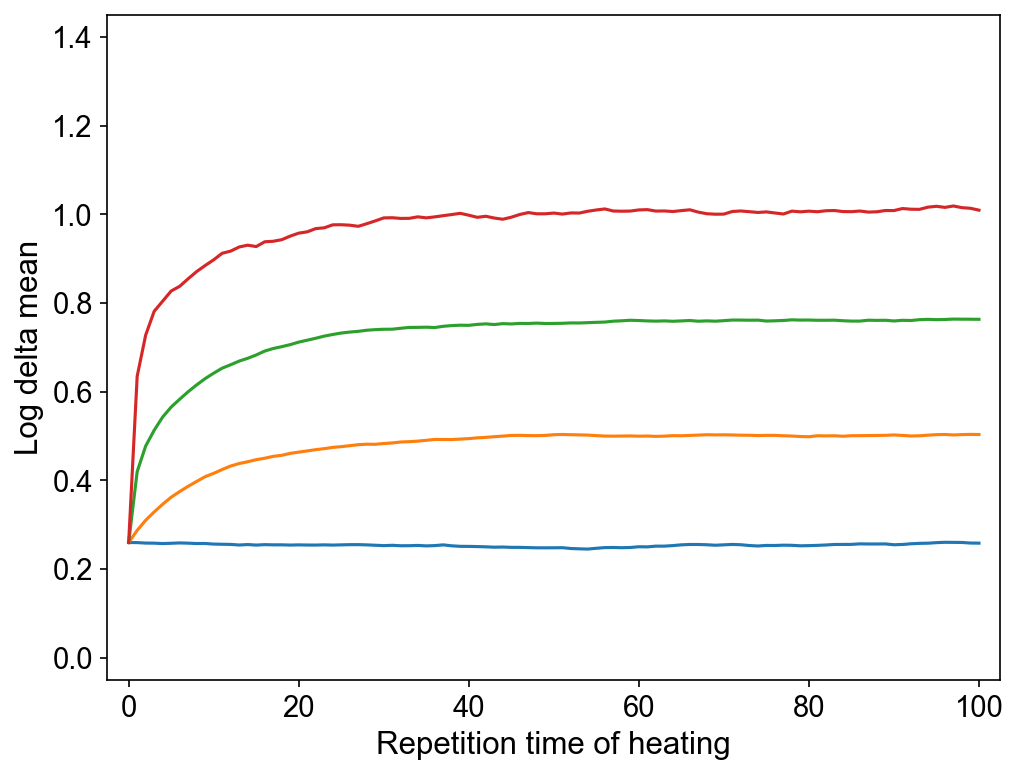

In [60]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.ylabel("Log delta mean",size=15,fontname="Arial")
plt.xlabel("Repetition time of heating",size=15,fontname="Arial")

plt.plot(range(revo_num+1),logPara_histories_rev_0_delta_mean, color = palette[0])
plt.plot(range(revo_num+1),logPara_histories_rev_delta_mean, color = palette[1])
plt.plot(range(revo_num+1),logPara_histories_rev_2_delta_mean, color = palette[2])
plt.plot(range(revo_num+1),logPara_histories_rev_3_delta_mean, color = palette[3])
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim([-0.05,1.45])
plt.xlim([-2.5,revo_num+2.5])
plt.savefig("Evo_Fig/Rev_delta_mean.pdf", bbox_inches="tight", dpi=150)
plt.show()

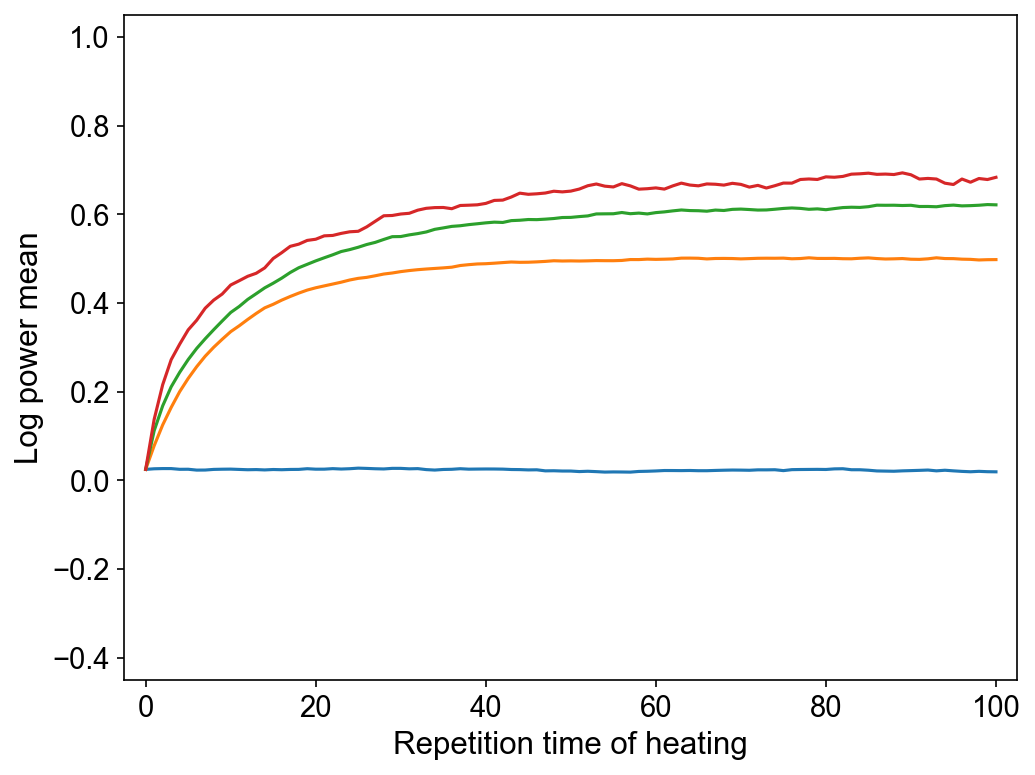

In [61]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.ylabel("Log power mean",size=15,fontname="Arial")
plt.xlabel("Repetition time of heating",size=15,fontname="Arial")

plt.plot(range(revo_num+1),logPara_histories_rev_0_power_mean, color = palette[0])
plt.plot(range(revo_num+1),logPara_histories_rev_power_mean, color = palette[1])
plt.plot(range(revo_num+1),logPara_histories_rev_2_power_mean, color = palette[2])
plt.plot(range(revo_num+1),logPara_histories_rev_3_power_mean, color = palette[3])
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim([-0.45,1.05])
plt.xlim([-2.5,revo_num+2.5])
plt.savefig("Evo_Fig/Rev_power_mean.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [62]:
survival_simulation_counts = pd.DataFrame()
for i in tqdm(range(revo_num+1),leave=False):
    survival_simulation_count_tmp = sim_num - np.sum(np.isnan(logPara_histories.loc[i]))/2
    survival_simulation_counts = pd.concat([survival_simulation_counts, pd.DataFrame([survival_simulation_count_tmp], index = [i], columns = ['Survivors'])], axis=0)

  0%|          | 0/101 [00:00<?, ?it/s]

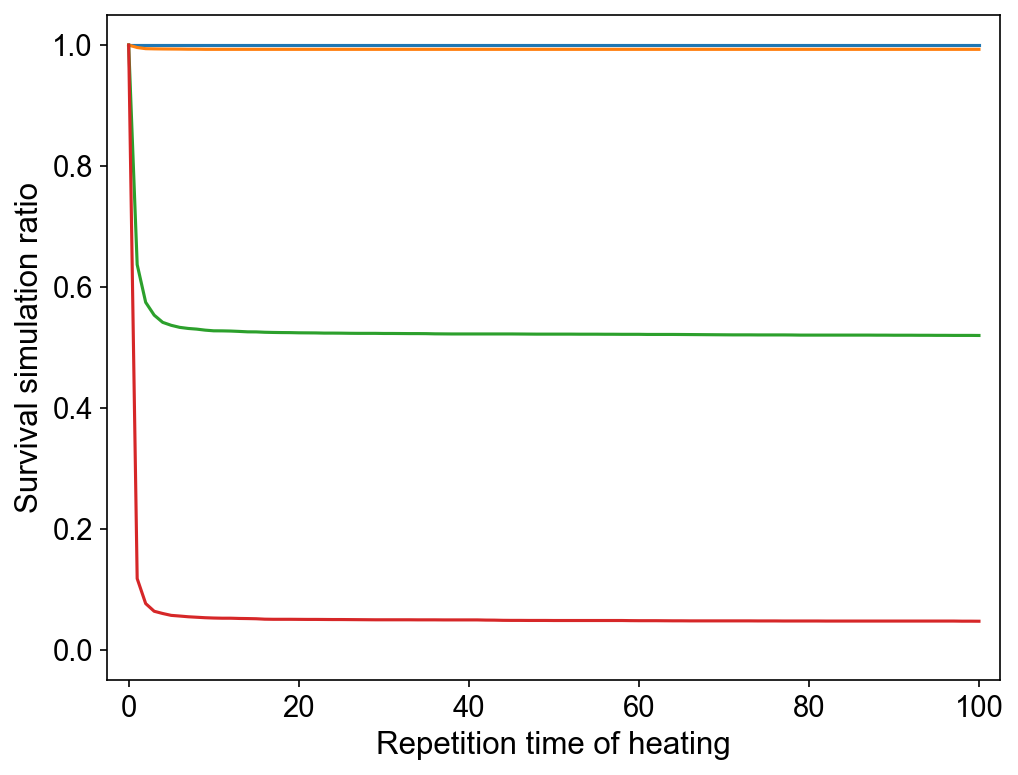

In [63]:
plt.figure(figsize=[6.4*1.2, 4.8*1.2], dpi=150)
plt.rcParams["font.family"] = "Arial"
plt.ylabel("Survival simulation ratio",size=15,fontname="Arial")
plt.xlabel("Repetition time of heating",size=15,fontname="Arial")
plt.plot(range(revo_num+1),survival_simulation_counts/sim_num, color = palette[0])
plt.plot(range(revo_num+1),Survival_simulation_ratio_rev, color = palette[1])
plt.plot(range(revo_num+1),Survival_simulation_ratio_rev_2, color = palette[2])
plt.plot(range(revo_num+1),Survival_simulation_ratio_rev_3, color = palette[3])
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim([-0.05,1.05])
plt.xlim([-2.5,revo_num+2.5])
plt.savefig("Evo_Fig/Rev simulation counts.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [64]:
Simed_params = {
    'delta': [],
    'power': [],
    'sim_name': []
}
Simed_paras = pd.DataFrame(Simed_params)

In [65]:
survival_simulation_counts = pd.DataFrame()
for i in tqdm(range(revo_num+1),leave=False):
    survival_simulation_count_tmp = sim_num - np.sum(np.isnan(logPara_histories.loc[i]))/2
    survival_simulation_counts = pd.concat([survival_simulation_counts, pd.DataFrame([survival_simulation_count_tmp], index = [i], columns = ['Survivors'])], axis=0)

  0%|          | 0/101 [00:00<?, ?it/s]

time_min = 0
time_max = 12
devide = (time_max-time_min)*10
time_interval = np.arange(time_min, time_max*(devide+1)/devide,
                          (time_max-time_min)/devide, dtype="float")

def Fit_Model(t, delta, power) :
    return -6*(t/6/delta)**power


logPara_histories_rev_survivors = logPara_histories_rev.dropna(axis=1)

Num_mcmc = sim_num
logS_credible_mcmc = np.zeros((len(time_interval),Num_mcmc), dtype=float)
logS_credible_mcmc_quantile = np.zeros((len(time_interval), 3), dtype=float)
logS_rev_credible_mcmc = np.zeros((len(time_interval),len(logPara_histories_rev.dropna(axis=1).columns)), dtype=float)
logS_rev_credible_mcmc_quantile = np.zeros((len(time_interval), 3), dtype=float)

for j in tqdm(range(len(time_interval)),desc='Progress', leave=False):
    for k in range(Num_mcmc):
        delta_sim = np.exp(logPara_histories['logdelta '+str(k)].dropna(how='all', axis=0).tail(1))
        power_sim = np.exp(logPara_histories['logdelta '+str(k)].dropna(how='all', axis=0).tail(1))
        logS_credible_mcmc[j,k] = Fit_Model(time_interval[j], delta_sim, power_sim)

    logS_credible_mcmc_quantile[j,:] = np.quantile(logS_credible_mcmc[j,:],[0.005,  0.5, 0.995])

for j in tqdm(range(len(time_interval)),desc='Progress', leave=False):
    for k in range(int(len(logPara_histories_rev.dropna(axis=1).columns)/2)):
        delta_sim = np.exp(logPara_histories_rev[logPara_histories_rev.dropna(axis=1).columns[k*2]].dropna(how='all', axis=0).tail(1))
        power_sim = np.exp(logPara_histories_rev[logPara_histories_rev.dropna(axis=1).columns[k*2+1]].dropna(how='all', axis=0).tail(1))
        logS_rev_credible_mcmc[j,k] = Fit_Model(time_interval[j], delta_sim, power_sim)

    logS_rev_credible_mcmc_quantile[j,:] = np.quantile(logS_rev_credible_mcmc[j,:],[0.005,  0.5, 0.995])

In [66]:
time_min = 0
time_max = 12
devide = (time_max-time_min)*10
time_interval = np.arange(time_min, time_max*(devide+1)/devide,
                          (time_max-time_min)/devide, dtype="float")

def Fit_Model(t, delta, power) :
    return -6*(t/6/delta)**power


logPara_histories_rev_survivors = logPara_histories_rev.dropna(axis=1)
logPara_histories_rev_2_survivors = logPara_histories_rev_2.dropna(axis=1)
logPara_histories_rev_3_survivors = logPara_histories_rev_3.dropna(axis=1)

Num_mcmc = sim_num
logS_credible_mcmc_list = np.zeros((len(time_interval),Num_mcmc), dtype=float)
logS_credible_mcmc_quantile = np.zeros((len(time_interval), 3), dtype=float)
logS_rev_credible_mcmc_list = np.zeros((len(time_interval),int(len(logPara_histories_rev.dropna(axis=1).columns)/2)), dtype=float)
logS_rev_credible_mcmc_quantile = np.zeros((len(time_interval), 3), dtype=float)
logS_rev_2_credible_mcmc_list = np.zeros((len(time_interval),int(len(logPara_histories_rev_2.dropna(axis=1).columns)/2)), dtype=float)
logS_rev_2_credible_mcmc_quantile = np.zeros((len(time_interval), 3), dtype=float)
logS_rev_3_credible_mcmc_list = np.zeros((len(time_interval),int(len(logPara_histories_rev_3.dropna(axis=1).columns)/2)), dtype=float)
logS_rev_3_credible_mcmc_quantile = np.zeros((len(time_interval), 3), dtype=float)


def Reductions(k):
    logS_credible_tmp = np.zeros(len(time_interval), dtype=float)
    for j in range(len(time_interval)):
        delta_sim = np.exp(logPara_histories['logdelta '+str(k)].dropna(how='all', axis=0).tail(1))
        power_sim = np.exp(logPara_histories['logdelta '+str(k)].dropna(how='all', axis=0).tail(1))
        logS_credible_tmp[j] = Fit_Model(time_interval[j], delta_sim, power_sim)
    return logS_credible_tmp

ns = range(Num_mcmc)
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(Reductions, ns)
logS_credible_mcmc = [r for r in ret]

for i in range(len(logS_credible_mcmc)):
    logS_credible_mcmc_list[:,i] = logS_credible_mcmc[i]

for j in tqdm(range(len(time_interval)),desc='Progress', leave=False):
    logS_credible_mcmc_quantile[j,:] = np.quantile(logS_credible_mcmc_list[j,:],[0.005,  0.5, 0.995])



def Reductions_rev(k):
    logS_credible_tmp = np.zeros(len(time_interval), dtype=float)
    for j in range(len(time_interval)):
        delta_sim = np.exp(logPara_histories_rev[logPara_histories_rev.dropna(axis=1).columns[k*2]].dropna(how='all', axis=0).tail(1))
        power_sim = np.exp(logPara_histories_rev[logPara_histories_rev.dropna(axis=1).columns[k*2+1]].dropna(how='all', axis=0).tail(1))
        logS_credible_tmp[j] = Fit_Model(time_interval[j], delta_sim, power_sim)
    return logS_credible_tmp

ns = range(int(len(logPara_histories_rev.dropna(axis=1).columns)/2))
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(Reductions_rev, ns)
logS_rev_credible_mcmc = [r for r in ret]

for i in range(len(logS_rev_credible_mcmc)):
    logS_rev_credible_mcmc_list[:,i] = logS_rev_credible_mcmc[i]

for j in tqdm(range(len(time_interval)),desc='Progress', leave=False):
    logS_rev_credible_mcmc_quantile[j,:] = np.quantile(logS_rev_credible_mcmc_list[j,:],[0.005,  0.5, 0.995])

    
def Reductions_rev_2(k):
    logS_credible_tmp = np.zeros(len(time_interval), dtype=float)
    for j in range(len(time_interval)):
        delta_sim = np.exp(logPara_histories_rev_2[logPara_histories_rev_2.dropna(axis=1).columns[k*2]].dropna(how='all', axis=0).tail(1))
        power_sim = np.exp(logPara_histories_rev_2[logPara_histories_rev_2.dropna(axis=1).columns[k*2+1]].dropna(how='all', axis=0).tail(1))
        logS_credible_tmp[j] = Fit_Model(time_interval[j], delta_sim, power_sim)
    return logS_credible_tmp

ns = range(int(len(logPara_histories_rev_2.dropna(axis=1).columns)/2))
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(Reductions_rev_2, ns)
logS_rev_2_credible_mcmc = [r for r in ret]

for i in range(len(logS_rev_2_credible_mcmc)):
    logS_rev_2_credible_mcmc_list[:,i] = logS_rev_2_credible_mcmc[i]

for j in tqdm(range(len(time_interval)),desc='Progress', leave=False):
    logS_rev_2_credible_mcmc_quantile[j,:] = np.quantile(logS_rev_2_credible_mcmc_list[j,:],[0.005,  0.5, 0.995])
    
    
def Reductions_rev_3(k):
    logS_credible_tmp = np.zeros(len(time_interval), dtype=float)
    for j in range(len(time_interval)):
        delta_sim = np.exp(logPara_histories_rev_3[logPara_histories_rev_3.dropna(axis=1).columns[k*2]].dropna(how='all', axis=0).tail(1))
        power_sim = np.exp(logPara_histories_rev_3[logPara_histories_rev_3.dropna(axis=1).columns[k*2+1]].dropna(how='all', axis=0).tail(1))
        logS_credible_tmp[j] = Fit_Model(time_interval[j], delta_sim, power_sim)
    return logS_credible_tmp

ns = range(int(len(logPara_histories_rev_3.dropna(axis=1).columns)/2))
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(Reductions_rev_3, ns)
logS_rev_3_credible_mcmc = [r for r in ret]

for i in range(len(logS_rev_3_credible_mcmc)):
    logS_rev_3_credible_mcmc_list[:,i] = logS_rev_3_credible_mcmc[i]

for j in tqdm(range(len(time_interval)),desc='Progress', leave=False):
    logS_rev_3_credible_mcmc_quantile[j,:] = np.quantile(logS_rev_3_credible_mcmc_list[j,:],[0.005,  0.5, 0.995])
    

Progress:   0%|          | 0/121 [00:00<?, ?it/s]

Progress:   0%|          | 0/121 [00:00<?, ?it/s]

Progress:   0%|          | 0/121 [00:00<?, ?it/s]

Progress:   0%|          | 0/121 [00:00<?, ?it/s]

In [67]:
len(logS_rev_credible_mcmc)

9929

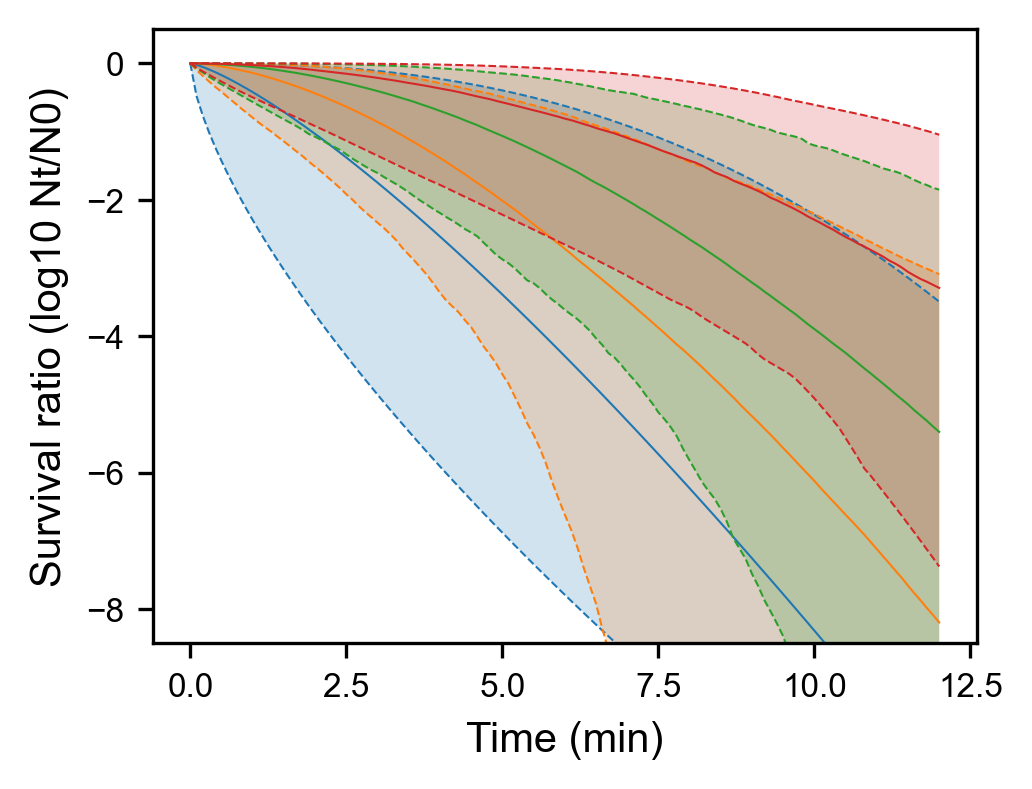

In [68]:
Palette = sns.color_palette(n_colors = 4)
plt.figure(figsize=(9*0.393701,9*0.393701*3/4), dpi=300)
plt.rcParams["font.family"] = "Arial"

plt.fill_between(time_interval, logS_credible_mcmc_quantile[:,0], logS_credible_mcmc_quantile[:,2], facecolor=Palette[0], alpha=0.2)
plt.fill_between(time_interval, logS_rev_credible_mcmc_quantile[:,0], logS_rev_credible_mcmc_quantile[:,2], facecolor=Palette[1], alpha=0.2)
plt.fill_between(time_interval, logS_rev_2_credible_mcmc_quantile[:,0], logS_rev_2_credible_mcmc_quantile[:,2], facecolor=Palette[2], alpha=0.2)
plt.fill_between(time_interval, logS_rev_3_credible_mcmc_quantile[:,0], logS_rev_3_credible_mcmc_quantile[:,2], facecolor=Palette[3], alpha=0.2)

plt.plot(time_interval, logS_credible_mcmc_quantile[:,0], lw=0.5,linestyle='--', color=Palette[0])
plt.plot(time_interval, logS_credible_mcmc_quantile[:,1], lw=0.5,linestyle='-', color=Palette[0])
plt.plot(time_interval, logS_credible_mcmc_quantile[:,2], lw=0.5,linestyle='--', color=Palette[0])
plt.plot(time_interval, logS_rev_credible_mcmc_quantile[:,0], lw=0.5,linestyle='--', color=Palette[1])
plt.plot(time_interval, logS_rev_credible_mcmc_quantile[:,1], lw=0.5,linestyle='-', color=Palette[1])
plt.plot(time_interval, logS_rev_credible_mcmc_quantile[:,2], lw=0.5,linestyle='--', color=Palette[1])
plt.plot(time_interval, logS_rev_2_credible_mcmc_quantile[:,0], lw=0.5,linestyle='--', color=Palette[2])
plt.plot(time_interval, logS_rev_2_credible_mcmc_quantile[:,1], lw=0.5,linestyle='-', color=Palette[2])
plt.plot(time_interval, logS_rev_2_credible_mcmc_quantile[:,2], lw=0.5,linestyle='--', color=Palette[2])
plt.plot(time_interval, logS_rev_3_credible_mcmc_quantile[:,0], lw=0.5,linestyle='--', color=Palette[3])
plt.plot(time_interval, logS_rev_3_credible_mcmc_quantile[:,1], lw=0.5,linestyle='-', color=Palette[3])
plt.plot(time_interval, logS_rev_3_credible_mcmc_quantile[:,2], lw=0.5,linestyle='--', color=Palette[3])

plt.xticks(size=8)
plt.yticks(size=8)
plt.xlabel("Time (min)",size=10,fontname="Arial")
plt.ylabel("Survival ratio (log10 Nt/N0)",size=10,fontname="Arial")
plt.ylim(-8.5,0.5)

plt.savefig("Evo_Fig/Prediction comparison.pdf", bbox_inches="tight", dpi=150)
plt.show()

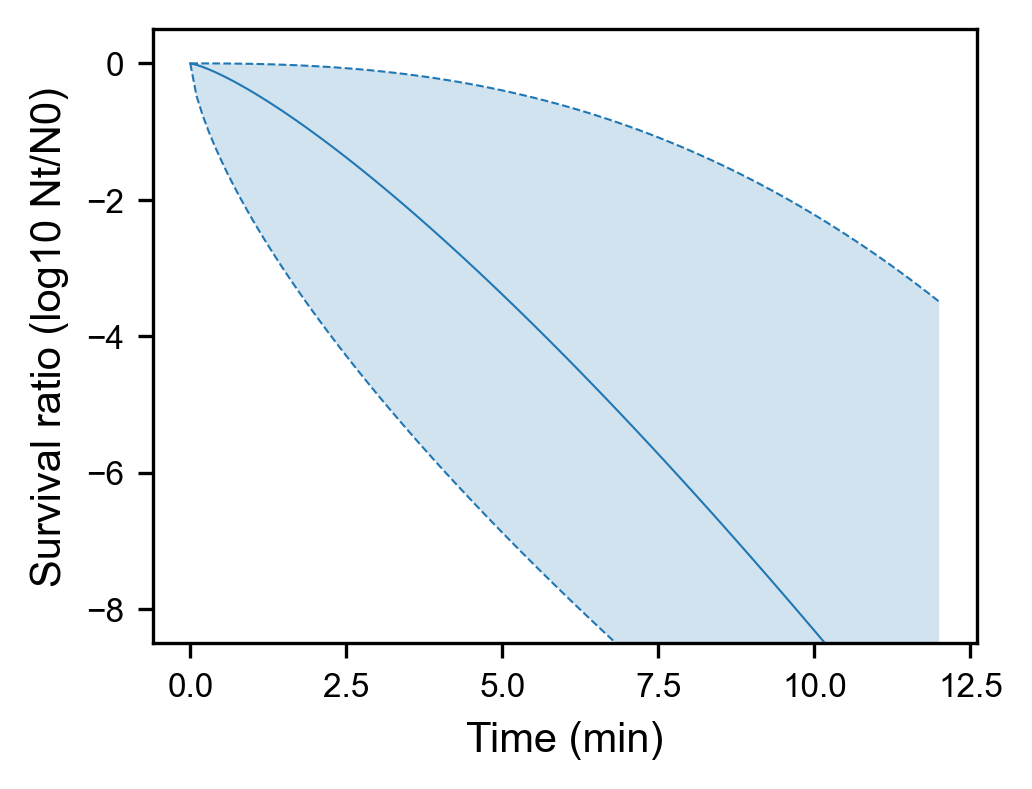

In [69]:
Palette = sns.color_palette(n_colors = 4)
plt.figure(figsize=(9*0.393701,9*0.393701*3/4), dpi=300)
plt.rcParams["font.family"] = "Arial"

plt.fill_between(time_interval, logS_credible_mcmc_quantile[:,0], logS_credible_mcmc_quantile[:,2], facecolor=Palette[0], alpha=0.2)

plt.plot(time_interval, logS_credible_mcmc_quantile[:,0], lw=0.5,linestyle='--', color=Palette[0])
plt.plot(time_interval, logS_credible_mcmc_quantile[:,1], lw=0.5,linestyle='-', color=Palette[0])
plt.plot(time_interval, logS_credible_mcmc_quantile[:,2], lw=0.5,linestyle='--', color=Palette[0])

plt.xticks(size=8)
plt.yticks(size=8)
plt.xlabel("Time (min)",size=10,fontname="Arial")
plt.ylabel("Survival ratio (log10 Nt/N0)",size=10,fontname="Arial")
plt.ylim(-8.5,0.5)

plt.savefig("Evo_Fig/Prediction comparison rev 0.pdf", bbox_inches="tight", dpi=150)
plt.show()

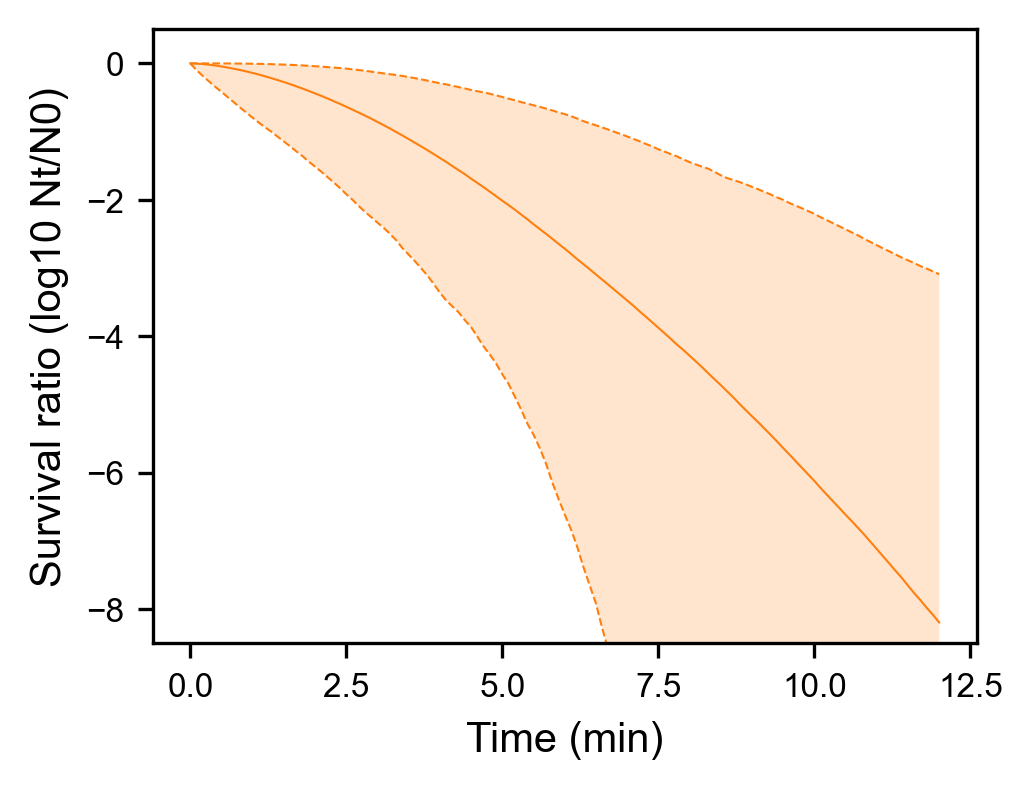

In [70]:
Palette = sns.color_palette(n_colors = 4)
plt.figure(figsize=(9*0.393701,9*0.393701*3/4), dpi=300)
plt.rcParams["font.family"] = "Arial"

plt.fill_between(time_interval, logS_rev_credible_mcmc_quantile[:,0], logS_rev_credible_mcmc_quantile[:,2], facecolor=Palette[1], alpha=0.2)

plt.plot(time_interval, logS_rev_credible_mcmc_quantile[:,0], lw=0.5,linestyle='--', color=Palette[1])
plt.plot(time_interval, logS_rev_credible_mcmc_quantile[:,1], lw=0.5,linestyle='-', color=Palette[1])
plt.plot(time_interval, logS_rev_credible_mcmc_quantile[:,2], lw=0.5,linestyle='--', color=Palette[1])

plt.xticks(size=8)
plt.yticks(size=8)
plt.xlabel("Time (min)",size=10,fontname="Arial")
plt.ylabel("Survival ratio (log10 Nt/N0)",size=10,fontname="Arial")
plt.ylim(-8.5,0.5)

plt.savefig("Evo_Fig/Prediction comparison rev 1.pdf", bbox_inches="tight", dpi=150)
plt.show()

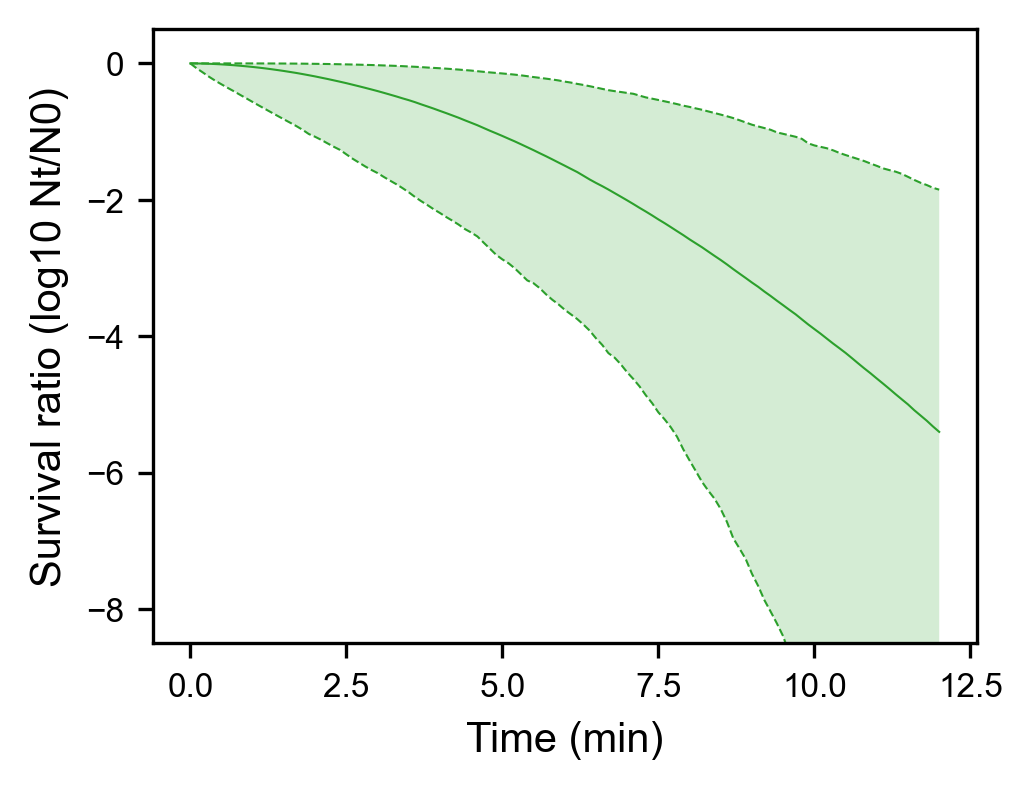

In [71]:
Palette = sns.color_palette(n_colors = 4)
plt.figure(figsize=(9*0.393701,9*0.393701*3/4), dpi=300)
plt.rcParams["font.family"] = "Arial"

plt.fill_between(time_interval, logS_rev_2_credible_mcmc_quantile[:,0], logS_rev_2_credible_mcmc_quantile[:,2], facecolor=Palette[2], alpha=0.2)

plt.plot(time_interval, logS_rev_2_credible_mcmc_quantile[:,0], lw=0.5,linestyle='--', color=Palette[2])
plt.plot(time_interval, logS_rev_2_credible_mcmc_quantile[:,1], lw=0.5,linestyle='-', color=Palette[2])
plt.plot(time_interval, logS_rev_2_credible_mcmc_quantile[:,2], lw=0.5,linestyle='--', color=Palette[2])

plt.xticks(size=8)
plt.yticks(size=8)
plt.xlabel("Time (min)",size=10,fontname="Arial")
plt.ylabel("Survival ratio (log10 Nt/N0)",size=10,fontname="Arial")
plt.ylim(-8.5,0.5)

plt.savefig("Evo_Fig/Prediction comparison rev 2.pdf", bbox_inches="tight", dpi=150)
plt.show()

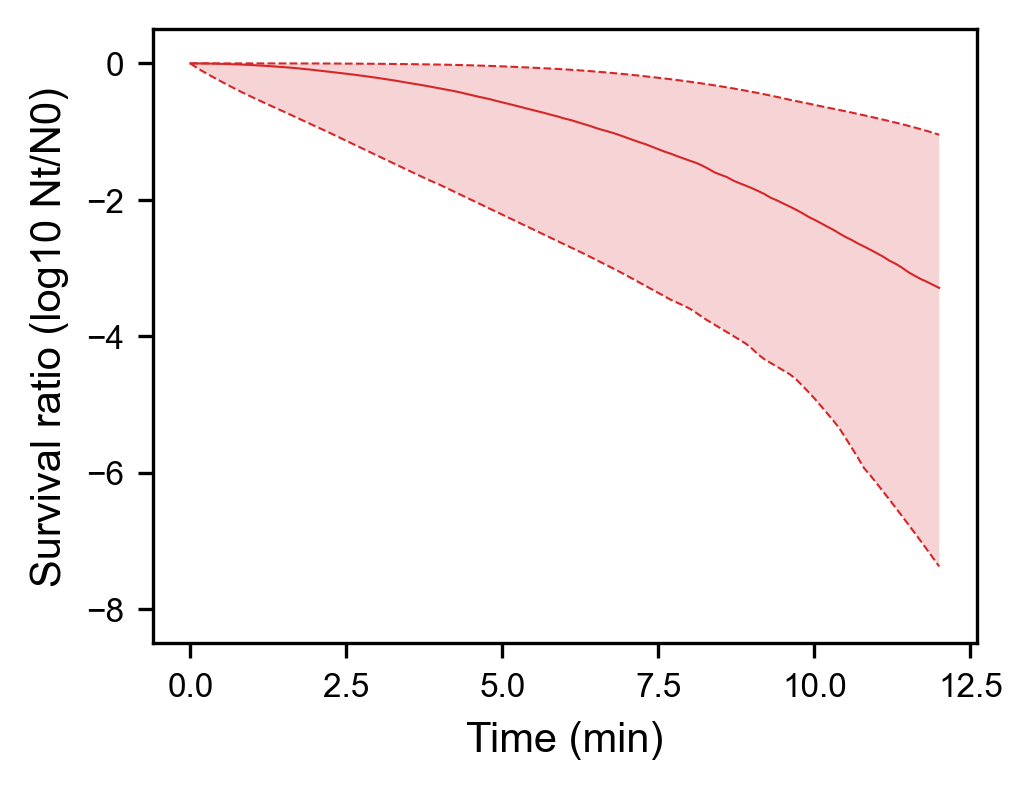

In [72]:
Palette = sns.color_palette(n_colors = 4)
plt.figure(figsize=(9*0.393701,9*0.393701*3/4), dpi=300)
plt.rcParams["font.family"] = "Arial"

plt.fill_between(time_interval, logS_rev_3_credible_mcmc_quantile[:,0], logS_rev_3_credible_mcmc_quantile[:,2], facecolor=Palette[3], alpha=0.2)

plt.plot(time_interval, logS_rev_3_credible_mcmc_quantile[:,0], lw=0.5,linestyle='--', color=Palette[3])
plt.plot(time_interval, logS_rev_3_credible_mcmc_quantile[:,1], lw=0.5,linestyle='-', color=Palette[3])
plt.plot(time_interval, logS_rev_3_credible_mcmc_quantile[:,2], lw=0.5,linestyle='--', color=Palette[3])

plt.xticks(size=8)
plt.yticks(size=8)
plt.xlabel("Time (min)",size=10,fontname="Arial")
plt.ylabel("Survival ratio (log10 Nt/N0)",size=10,fontname="Arial")
plt.ylim(-8.5,0.5)

plt.savefig("Evo_Fig/Prediction comparison rev 3.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [73]:
logS_rev_credible_mcmc_quantile

array([[-0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-9.90584523e-02, -3.22401640e-03, -3.77298414e-06],
       [-1.83230268e-01, -1.00506152e-02, -3.38926171e-05],
       [-2.63908424e-01, -1.95903078e-02, -1.18129260e-04],
       [-3.44462646e-01, -3.13665986e-02, -2.91201967e-04],
       [-4.16788160e-01, -4.53486541e-02, -5.89807937e-04],
       [-4.95629893e-01, -6.10709238e-02, -1.02047527e-03],
       [-5.71406327e-01, -7.86112474e-02, -1.66229877e-03],
       [-6.49765453e-01, -9.77934810e-02, -2.52525341e-03],
       [-7.22318660e-01, -1.18203335e-01, -3.70517055e-03],
       [-7.97109097e-01, -1.40464743e-01, -5.20446448e-03],
       [-8.69832111e-01, -1.63969731e-01, -7.04333494e-03],
       [-9.37855017e-01, -1.89450524e-01, -9.19807556e-03],
       [-1.00265803e+00, -2.16396981e-01, -1.17378982e-02],
       [-1.07494201e+00, -2.44409453e-01, -1.46287761e-02],
       [-1.14420218e+00, -2.73650590e-01, -1.76025846e-02],
       [-1.21640040e+00, -3.04199571e-01

In [74]:
logS_credible_mcmc_quantile

array([[-0.00000000e+00, -0.00000000e+00,  0.00000000e+00],
       [-4.77460386e-01, -2.13395381e-02, -2.36699395e-05],
       [-7.65986687e-01, -5.23759161e-02, -1.32613234e-04],
       [-1.00996098e+00, -8.85596278e-02, -3.63384845e-04],
       [-1.22886763e+00, -1.28551827e-01, -7.42979166e-04],
       [-1.43084224e+00, -1.71637835e-01, -1.29391081e-03],
       [-1.62027406e+00, -2.17361392e-01, -2.03590079e-03],
       [-1.79987382e+00, -2.65401627e-01, -2.98670850e-03],
       [-1.97146463e+00, -3.15518537e-01, -4.16261705e-03],
       [-2.13634730e+00, -3.67524724e-01, -5.57874621e-03],
       [-2.29549125e+00, -4.21269147e-01, -7.24926839e-03],
       [-2.44964358e+00, -4.76627053e-01, -9.18756497e-03],
       [-2.59939553e+00, -5.33493379e-01, -1.14063440e-02],
       [-2.74522523e+00, -5.91778231e-01, -1.39177312e-02],
       [-2.88752631e+00, -6.51403681e-01, -1.67333426e-02],
       [-3.02662783e+00, -7.12301418e-01, -1.98643425e-02],
       [-3.16280839e+00, -7.74410990e-01

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

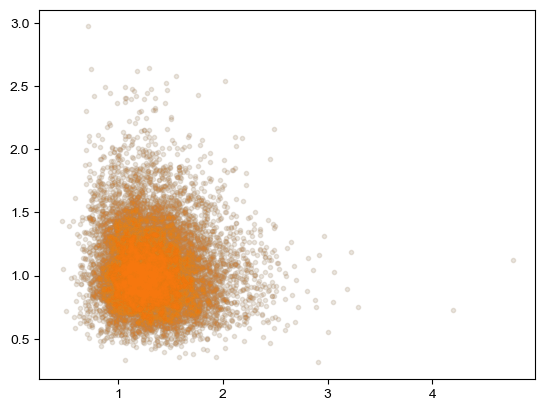

In [75]:
for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories_non['logdelta '+str(j)].head(1)),np.exp(logPara_histories_non['logpower '+str(j)].head(1)), marker = '.', color = palette[0], alpha=0.1)
for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories_rev['logdelta '+str(j)].head(1)),np.exp(logPara_histories_rev['logpower '+str(j)].head(1)), marker = '.', color = palette[1], alpha=0.1)
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

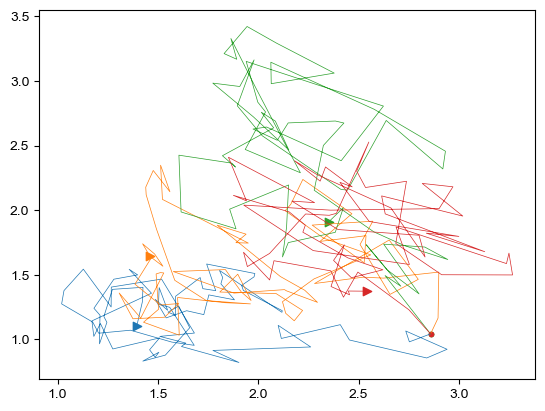

In [76]:
palette = sns.color_palette(n_colors = sim_num)
for j in tqdm([153],leave=False):
    plt.plot(np.exp(logPara_histories_non['logdelta '+str(j)]),np.exp(logPara_histories_non['logpower '+str(j)]), linewidth = 0.5, color = palette[0])
    plt.scatter(np.exp(logPara_histories_non['logdelta '+str(j)].head(1)),np.exp(logPara_histories_non['logpower '+str(j)].head(1)), marker = '.', color = palette[0])
    plt.scatter(np.exp(logPara_histories_non['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_non['logpower '+str(j)].tail(1)), marker = '>', color = palette[0])
    plt.plot(np.exp(logPara_histories_rev['logdelta '+str(j)]),np.exp(logPara_histories_rev['logpower '+str(j)]), linewidth = 0.5, color = palette[1])
    plt.scatter(np.exp(logPara_histories_rev['logdelta '+str(j)].head(1)),np.exp(logPara_histories_rev['logpower '+str(j)].head(1)), marker = '.', color = palette[1])
    plt.scatter(np.exp(logPara_histories_rev['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev['logpower '+str(j)].tail(1)), marker = '>', color  = palette[1])
    plt.plot(np.exp(logPara_histories_rev_2['logdelta '+str(j)]),np.exp(logPara_histories_rev_2['logpower '+str(j)]), linewidth = 0.5, color = palette[2])
    plt.scatter(np.exp(logPara_histories_rev_2['logdelta '+str(j)].head(1)),np.exp(logPara_histories_rev_2['logpower '+str(j)].head(1)), marker = '.', color = palette[2])
    plt.scatter(np.exp(logPara_histories_rev_2['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev_2['logpower '+str(j)].tail(1)), marker = '>', color  = palette[2])
    plt.plot(np.exp(logPara_histories_rev_3['logdelta '+str(j)]),np.exp(logPara_histories_rev_3['logpower '+str(j)]), linewidth = 0.5, color = palette[3])
    plt.scatter(np.exp(logPara_histories_rev_3['logdelta '+str(j)].head(1)),np.exp(logPara_histories_rev_3['logpower '+str(j)].head(1)), marker = '.', color = palette[3])
    plt.scatter(np.exp(logPara_histories_rev_3['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev_3['logpower '+str(j)].tail(1)), marker = '>', color  = palette[3])
plt.show()

In [77]:
sim_num = 1000
revo_num = 100
cell_counts = 10**6
thermal_trial_lim = 100
L_para = 1
processor_num = 8

In [78]:
t_heating = 10
warnings.simplefilter('ignore', RuntimeWarning)
Sim_results =[]
ns = range(sim_num)
with ProcessPoolExecutor(processor_num) as e:
    ret = e.map(heat_rev, ns)
logPara_histories = [r for r in ret]
logPara_histories = pd.concat(logPara_histories, axis=1)

  0%|          | 0/1000 [00:00<?, ?it/s]

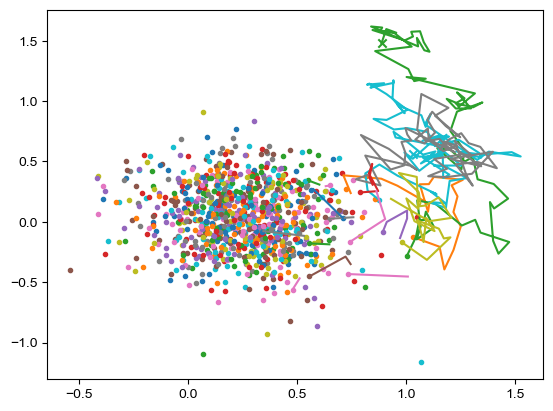

In [79]:
palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(logPara_histories['logdelta '+str(j)],logPara_histories['logpower '+str(j)], color = palette[j])
    plt.scatter(logPara_histories['logdelta '+str(j)].head(1),logPara_histories['logpower '+str(j)].head(1), marker = '.', color = palette[j])
    plt.scatter(logPara_histories['logdelta '+str(j)].tail(1),logPara_histories['logpower '+str(j)].tail(1), marker = 'x', color = palette[j])
plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

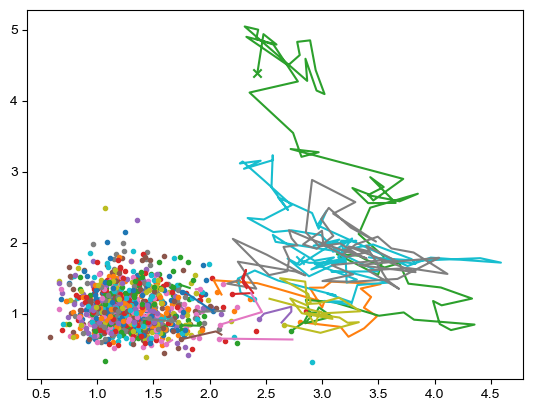

In [80]:
palette = sns.color_palette(n_colors = sim_num)
for j in tqdm(range(sim_num),leave=False):
    plt.plot(np.exp(logPara_histories['logdelta '+str(j)]),np.exp(logPara_histories['logpower '+str(j)]), color = palette[j])
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].head(1)),np.exp(logPara_histories['logpower '+str(j)].head(1)), marker = '.', color = palette[j])
    plt.scatter(np.exp(logPara_histories['logdelta '+str(j)].tail(1)),np.exp(logPara_histories['logpower '+str(j)].tail(1)), marker = 'x', color = palette[j])
plt.show()

In [81]:
logPara_histories_rev_L_para_01 = logPara_histories

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

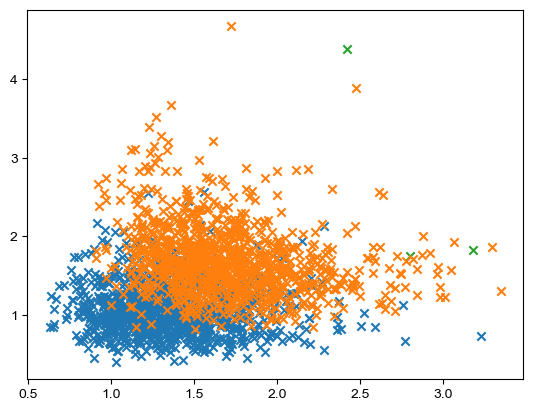

In [82]:
for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories_rev_L_para_01['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev_L_para_01['logpower '+str(j)].tail(1)), marker = 'x', color = palette[2])
for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories_non['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_non['logpower '+str(j)].tail(1)), marker = 'x', color = palette[0])
for j in tqdm(range(sim_num),leave=False):
    plt.scatter(np.exp(logPara_histories_rev['logdelta '+str(j)].tail(1)),np.exp(logPara_histories_rev['logpower '+str(j)].tail(1)), marker = 'x', color = palette[1])
plt.show()